# Credora Finance — Credit Risk & Loan Approval Analytics Platform

## Exploratory Data Analysis (EDA)

### Objective

The objective of this exploratory data analysis is to understand the structure,
quality, distributions, and relationships within the Credora Finance datasets
before feature engineering and predictive modeling.

The analysis focuses on four key data sources:

- Customer demographic and financial information
- Credit history and credit behavior
- Loan application and repayment outcomes
- Customer transaction activity

Special attention is given to the `loan_default` target variable, as it will be
used to develop the credit risk prediction model.

## 1. Import Required Libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Datasets

The project consists of four datasets representing different aspects of a
customer's financial profile. These datasets are loaded separately and will
be examined before any integration or feature engineering is performed.

In [20]:
customers = pd.read_csv("customers.csv")
credit = pd.read_csv("credit_history.csv")
loans = pd.read_csv("loan_applications.csv")
transactions = pd.read_csv("transactions.csv")

## 3. Dataset Overview

### 3.1 Dataset Dimensions

The dimensions of each dataset are examined to understand the number of
observations and variables available for analysis.

In [21]:
print(customers.shape)
print(credit.shape)
print(loans.shape)
print(transactions.shape)

(5000, 20)
(5000, 14)
(7500, 17)
(40079, 8)


**Observation:**  
The customer and credit history datasets each contain 5,000 records, while
the loan application dataset contains 7,500 records, indicating that a
customer may have more than one loan application. The transaction dataset
contains 40,079 records, representing multiple transactions per customer.

### 3.2 Preview of the Datasets

In [31]:
display(customers.head())
display(credit.head())
display(loans.head())
display(transactions.head())

,customer_id,first_name,last_name,gender,date_of_birth,age,marital_status,dependents,education,employment_type,occupation,annual_income,city,state,residence_type,years_at_residence,email,phone,kyc_status,customer_since
0,CUST100001,Kabir,Kulkarni,Male,2004-09-09,21,Married,1,Diploma,Salaried,Software Engineer,316400,Noida,Uttar Pradesh,Family Owned,3,kabir.kulkarni614@outlook.com,+91-8574623268,Verified,2023-06-16
1,CUST100002,Manish,Gupta,Male,1997-03-06,29,Married,1,Graduate,Unemployed,Student,120000,Mysuru,Karnataka,Mortgaged,11,manish.gupta34@gmail.com,+91-9252972703,Verified,2014-08-15
2,CUST100003,Sandeep,Mehta,Male,2001-08-02,24,Married,0,Diploma,Salaried,Nurse,175800,Kochi,Kerala,Owned,6,sandeep.mehta434@outlook.com,+91-9113744447,Pending,2023-04-29
3,CUST100004,Kabir,Reddy,Male,1976-03-30,50,Single,3,Graduate,Retired,Retired Private Sector,275100,Bengaluru,Karnataka,Rented,24,kabir.reddy27@gmail.com,+91-7697018056,Verified,2016-11-03
4,CUST100005,Saanvi,Patel,Female,1993-04-05,33,Married,1,Diploma,Self-Employed,Doctor (Practice),384700,Pune,Maharashtra,Owned,7,saanvi.patel597@outlook.com,+91-7148556853,Verified,2017-09-24


,credit_id,customer_id,as_of_date,credit_score,num_open_accounts,num_credit_inquiries_6m,credit_utilization_ratio,num_late_payments_30d,num_late_payments_90d,num_defaults_prior,bankruptcies,total_credit_limit,total_outstanding_debt,oldest_account_age_months
0,CR500001,CUST100001,2024-06-30,631,4,1,0.707,2,0,0,0,184000,130100,6
1,CR500002,CUST100002,2024-06-30,429,5,1,0.748,3,2,1,1,58000,43400,66
2,CR500003,CUST100003,2024-06-30,503,2,4,0.658,2,2,0,0,128000,84200,30
3,CR500004,CUST100004,2024-06-30,576,5,4,0.373,0,0,0,0,218000,81300,344
4,CR500005,CUST100005,2024-06-30,681,6,1,0.155,1,1,0,0,91000,14100,105


,application_id,customer_id,application_date,loan_type,loan_purpose,requested_amount,loan_term_months,interest_rate,applicant_monthly_income,existing_emi,debt_to_income_ratio,collateral_flag,approval_status,approved_amount,decision_date,disbursed_flag,loan_default
0,APP800001,CUST101595,2022-12-20,Business,Equipment Purchase,6297000,84,15.25,48400,11600,2.769,0,Rejected,0,2022-12-27,0,NaN
1,APP800002,CUST104584,2022-12-15,Home,Balance Transfer,6050000,24,10.07,149200,21700,2.017,1,Rejected,0,2022-12-31,0,NaN
2,APP800003,CUST103833,2022-10-05,Business,Equipment Purchase,6441000,48,17.51,88500,13900,2.277,0,Rejected,0,2022-10-19,0,NaN
3,APP800004,CUST103841,2022-08-29,Auto,Used Car,2498000,24,9.79,42300,14400,3.000,1,Rejected,0,2022-09-09,0,NaN
4,APP800005,CUST100115,2024-05-22,Gold,Gold Loan,393000,24,12.86,47300,5200,0.505,1,Under Review,0,NaN,0,NaN


,transaction_id,customer_id,transaction_date,transaction_type,category,channel,amount,balance_after
0,TXN1004290,CUST100532,2024-01-01,Debit,Dining,Net Banking,1446.39,3787.47
1,TXN1024738,CUST103082,2024-01-01,Credit,Salary,Debit Card,42535.79,133222.97
2,TXN1029304,CUST103653,2024-01-01,Debit,Travel,Net Banking,6418.24,149138.52
3,TXN1021143,CUST102626,2024-01-01,Debit,ATM Withdrawal,Credit Card,7319.62,122052.09
4,TXN1018214,CUST102262,2024-01-01,Debit,EMI,UPI,3950.95,21520.30


### 3.3 Column Structure

The column names of each dataset are examined to understand the available
variables and their relevance to customer information, credit history,
loan applications, and transaction behavior.

Reviewing the column structure helps identify potential features, target
variables, identifiers, and fields that may be useful in later stages of
exploratory analysis and predictive modeling.

In [23]:
print("CUSTOMERS")
display(customers.describe())

print("\nCREDIT HISTORY")
display(credit.describe())

print("\nLOAN APPLICATIONS")
display(loans.describe())

print("\nTRANSACTIONS")
display(transactions.describe())

CUSTOMERS


,age,dependents,annual_income,years_at_residence
count,5000.000000,5000.000000,5.000000e+03,5000.00000
mean,38.388400,1.319200,5.795758e+05,9.94840
std,10.560277,1.135063,4.225968e+05,6.52842
min,21.000000,0.000000,1.200000e+05,0.00000
25%,30.000000,0.000000,2.941750e+05,4.00000
50%,38.000000,1.000000,4.748000e+05,9.00000
75%,46.000000,2.000000,7.280500e+05,15.00000
max,74.000000,6.000000,4.636900e+06,24.00000



CREDIT HISTORY


,credit_score,num_open_accounts,num_credit_inquiries_6m,credit_utilization_ratio,num_late_payments_30d,num_late_payments_90d,num_defaults_prior,bankruptcies,total_credit_limit,total_outstanding_debt,oldest_account_age_months
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000
mean,648.93440,3.490400,1.670400,0.368043,1.29320,0.258400,0.161800,0.001800,3.193644e+05,1.095843e+05,192.691600
std,85.40396,1.848294,1.326694,0.187692,1.45026,0.586258,0.486691,0.042392,2.769357e+05,1.116656e+05,122.504552
min,300.00000,0.000000,0.000000,0.020000,0.00000,0.000000,0.000000,0.000000,2.500000e+04,2.500000e+03,6.000000
25%,595.00000,2.000000,1.000000,0.222000,0.00000,0.000000,0.000000,0.000000,1.380000e+05,4.040000e+04,96.000000
50%,652.00000,3.000000,1.000000,0.353000,1.00000,0.000000,0.000000,0.000000,2.435000e+05,7.530000e+04,190.000000
75%,706.00000,5.000000,2.000000,0.502000,2.00000,0.000000,0.000000,0.000000,4.070000e+05,1.396000e+05,281.000000
max,900.00000,14.000000,8.000000,0.990000,9.00000,5.000000,4.000000,1.000000,3.651000e+06,1.682000e+06,480.000000



LOAN APPLICATIONS


,requested_amount,loan_term_months,interest_rate,applicant_monthly_income,existing_emi,debt_to_income_ratio,collateral_flag,approved_amount,disbursed_flag,loan_default
count,7.500000e+03,7500.00000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7.500000e+03,7500.000000,3403.000000
mean,2.368134e+06,50.51680,13.744532,48526.733333,8395.506667,1.570814,0.521200,5.883009e+05,0.453733,0.234205
std,2.698808e+06,40.37292,4.124718,35707.059254,8885.046334,1.023409,0.499584,1.288144e+06,0.497888,0.423563
min,3.100000e+04,12.00000,8.010000,10000.000000,0.000000,0.036000,0.000000,0.000000e+00,0.000000,0.000000
25%,6.200000e+05,24.00000,10.290000,25275.000000,2700.000000,0.631000,0.000000,0.000000e+00,0.000000,0.000000
50%,1.288000e+06,36.00000,12.740000,39900.000000,5900.000000,1.314000,1.000000,0.000000e+00,0.000000,0.000000
75%,2.873750e+06,60.00000,16.590000,60400.000000,11000.000000,2.894250,1.000000,6.450000e+05,1.000000,0.000000
max,1.200000e+07,240.00000,24.000000,386400.000000,108200.000000,3.000000,1.000000,1.171600e+07,1.000000,1.000000



TRANSACTIONS


,amount,balance_after
count,40079.000000,4.007900e+04
mean,14040.707134,8.000340e+04
std,18835.280337,7.786162e+04
min,100.390000,1.000000e+02
25%,3566.420000,2.848772e+04
50%,7928.110000,5.757170e+04
75%,16313.230000,1.051002e+05
max,359766.320000,1.268816e+06


In [24]:
display(customers.describe(include="all"))

,customer_id,first_name,last_name,gender,date_of_birth,age,marital_status,dependents,education,employment_type,occupation,annual_income,city,state,residence_type,years_at_residence,email,phone,kyc_status,customer_since
count,5000,5000,5000,5000,5000,5000.000000,5000,5000.000000,5000,5000,5000,5.000000e+03,5000,5000,5000,5000.00000,5000,5000,5000,5000
unique,5000,60,30,2,4115,NaN,4,NaN,5,5,25,NaN,20,13,4,NaN,4998,5000,2,2842
top,CUST105000,Amit,Mehta,Male,2005-02-24,NaN,Married,NaN,Graduate,Salaried,Sales Executive,NaN,Noida,Maharashtra,Rented,NaN,divya.mukherjee158@rediffmail.com,+91-7292304919,Verified,2019-08-14
freq,1,122,198,2916,6,NaN,2689,NaN,2141,2707,359,NaN,275,766,1861,NaN,2,1,3720,7
mean,NaN,NaN,NaN,NaN,NaN,38.388400,NaN,1.319200,NaN,NaN,NaN,5.795758e+05,NaN,NaN,NaN,9.94840,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,10.560277,NaN,1.135063,NaN,NaN,NaN,4.225968e+05,NaN,NaN,NaN,6.52842,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,21.000000,NaN,0.000000,NaN,NaN,NaN,1.200000e+05,NaN,NaN,NaN,0.00000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,30.000000,NaN,0.000000,NaN,NaN,NaN,2.941750e+05,NaN,NaN,NaN,4.00000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,38.000000,NaN,1.000000,NaN,NaN,NaN,4.748000e+05,NaN,NaN,NaN,9.00000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,46.000000,NaN,2.000000,NaN,NaN,NaN,7.280500e+05,NaN,NaN,NaN,15.00000,NaN,NaN,NaN,NaN


### 3.4 Dataset Information and Data Types

The structure and data types of each dataset are examined to understand how
the variables are stored and to identify any columns that may require type
conversion before further analysis.

In [32]:
print("CUSTOMERS")
customers.info()

print("\nCREDIT HISTORY")
credit.info()

print("\nLOAN APPLICATIONS")
loans.info()

print("\nTRANSACTIONS")
transactions.info()

CUSTOMERS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   customer_id         5000 non-null   object
 1   first_name          5000 non-null   object
 2   last_name           5000 non-null   object
 3   gender              5000 non-null   object
 4   date_of_birth       5000 non-null   object
 5   age                 5000 non-null   int64 
 6   marital_status      5000 non-null   object
 7   dependents          5000 non-null   int64 
 8   education           5000 non-null   object
 9   employment_type     5000 non-null   object
 10  occupation          5000 non-null   object
 11  annual_income       5000 non-null   int64 
 12  city                5000 non-null   object
 13  state               5000 non-null   object
 14  residence_type      5000 non-null   object
 15  years_at_residence  5000 non-null   int64 
 16  email         

## 4. Data Quality Assessment

### 4.1 Missing Value Analysis

Missing values are examined across all four datasets to identify incomplete
records and determine whether any missing values require further investigation,
removal, or treatment before analysis and modeling.

In [33]:
print("CUSTOMERS")
display(customers.isnull().sum())

print("\nCREDIT HISTORY")
display(credit.isnull().sum())

print("\nLOAN APPLICATIONS")
display(loans.isnull().sum())

print("\nTRANSACTIONS")
display(transactions.isnull().sum())

CUSTOMERS


,0
customer_id,0
first_name,0
last_name,0
gender,0
date_of_birth,0
age,0
marital_status,0
dependents,0
education,0
employment_type,0



CREDIT HISTORY


,0
credit_id,0
customer_id,0
as_of_date,0
credit_score,0
num_open_accounts,0
num_credit_inquiries_6m,0
credit_utilization_ratio,0
num_late_payments_30d,0
num_late_payments_90d,0
num_defaults_prior,0



LOAN APPLICATIONS


,0
application_id,0
customer_id,0
application_date,0
loan_type,0
loan_purpose,0
requested_amount,0
loan_term_months,0
interest_rate,0
applicant_monthly_income,0
existing_emi,0



TRANSACTIONS


,0
transaction_id,0
customer_id,0
transaction_date,0
transaction_type,0
category,0
channel,0
amount,0
balance_after,0


## 5. Target Variable Analysis

### 5.1 Loan Default Distribution

The `loan_default` variable is the target variable for the credit risk
prediction model. Its distribution is examined to understand the proportion
of default, non-default, and missing outcomes in the loan application dataset.

The normalized distribution is calculated to express each category as a
proportion of the total loan applications.

In [27]:
print(loans["loan_default"].value_counts(normalize=True, dropna=False))

loan_default
NaN    0.546267
0.0    0.347467
1.0    0.106267
Name: proportion, dtype: float64


### 5.2 Loan Default by Approval Status

Since a large number of loan applications have missing values in the
`loan_default` target variable, the relationship between `approval_status`
and `loan_default` is examined.

A cross-tabulation is used to determine whether the availability of a default
outcome is associated with the loan approval status.

In [29]:
pd.crosstab(
    loans["approval_status"],
    loans["loan_default"],
    dropna=False
)

loan_default,0.0,1.0,NaN
approval_status,,,
Approved,2606,797,0
Rejected,0,0,3924
Under Review,0,0,173


#### Findings

- All **3,403 approved loan applications** have a recorded loan default outcome.
- Among the approved applications, **2,606 loans did not default**, while **797 loans defaulted**.
- All **3,924 rejected applications** have missing values for `loan_default`.
- All **173 applications under review** also have missing values for `loan_default`.
- Therefore, the missing values in `loan_default` are not random; they are associated with rejected and under-review applications.

#### EDA Implication

The missing `loan_default` values should **not be imputed as 0 (non-default)**, because these applications do not have an observed default outcome. The relationship between loan disbursement and default availability will be examined next to determine the appropriate records for credit risk modeling.

### 5.3 Loan Default by Disbursement Status

To further investigate the missing values in the `loan_default` target,
the relationship between loan disbursement status and default outcome is examined.

The `disbursed_flag` indicates whether a loan was actually disbursed to the
customer. This analysis helps determine whether default outcomes are available
only for loans that were disbursed.

In [30]:
pd.crosstab(
    loans["disbursed_flag"],
    loans["loan_default"],
    dropna=False
)

loan_default,0.0,1.0,NaN
disbursed_flag,,,
0,0,0,4097
1,2606,797,0


#### Findings

- All **4,097 non-disbursed loan applications** have missing values for `loan_default`.
- All **3,403 disbursed loans** have a recorded default outcome.
- Among the disbursed loans, **2,606 are non-default cases** and **797 are default cases**.
- Therefore, the missing values in `loan_default` are directly associated with loans that were not disbursed.

#### EDA Implication

The `loan_default` target is observed only for disbursed loans. Therefore,
the missing target values should not be imputed or interpreted as non-default
cases.

For predictive modeling, only disbursed loans with known `loan_default`
values will be used as labeled observations. The complete loan application
dataset will be retained for descriptive and business analysis.

## 6. Duplicate Record Analysis

Duplicate records can introduce bias and distort statistical analysis and model
training. Therefore, each dataset is checked for completely duplicated rows
before proceeding with further exploratory analysis.

In addition to full-row duplicates, the uniqueness of key identifier columns
is examined to ensure that the datasets follow their expected structure.

In [34]:
# Check completely duplicated rows in each dataset

print("Duplicate Rows")
print("-" * 40)

print("Customers:", customers.duplicated().sum())
print("Credit History:", credit.duplicated().sum())
print("Loan Applications:", loans.duplicated().sum())
print("Transactions:", transactions.duplicated().sum())

Duplicate Rows
----------------------------------------
Customers: 0
Credit History: 0
Loan Applications: 0
Transactions: 0


In [35]:
# Check uniqueness of primary identifiers

print("Unique ID Check")
print("-" * 40)

print(
    "Customers:",
    customers["customer_id"].nunique(),
    "unique IDs out of",
    len(customers),
    "rows"
)

print(
    "Credit History:",
    credit["credit_id"].nunique(),
    "unique IDs out of",
    len(credit),
    "rows"
)

print(
    "Loan Applications:",
    loans["application_id"].nunique(),
    "unique IDs out of",
    len(loans),
    "rows"
)

print(
    "Transactions:",
    transactions["transaction_id"].nunique(),
    "unique IDs out of",
    len(transactions),
    "rows"
)

Unique ID Check
----------------------------------------
Customers: 5000 unique IDs out of 5000 rows
Credit History: 5000 unique IDs out of 5000 rows
Loan Applications: 7500 unique IDs out of 7500 rows
Transactions: 40079 unique IDs out of 40079 rows


### Key Findings

- No completely duplicated rows were identified in any of the four datasets.
- The `customer_id` in the customer dataset contains **5,000 unique values across 5,000 records**.
- The `credit_id` in the credit history dataset contains **5,000 unique values across 5,000 records**.
- The `application_id` in the loan application dataset contains **7,500 unique values across 7,500 records**.
- The `transaction_id` in the transaction dataset contains **40,079 unique values across 40,079 records**.
- Therefore, no duplicate removal is required at this stage, and the primary record identifiers are unique within their respective datasets.

## 7. Data Type and Date Validation

Before performing further exploratory analysis, the data types of important
variables are validated. In particular, date-related columns are examined to
determine whether they are stored as proper datetime values.

Correct data types are necessary for reliable time-based analysis, feature
engineering, and visualization.

In [36]:
# Check data types of date-related columns

date_columns = {
    "Customers": ["date_of_birth", "customer_since"],
    "Credit History": ["as_of_date"],
    "Loan Applications": ["application_date", "decision_date"],
    "Transactions": ["transaction_date"]
}

for dataset_name, columns in date_columns.items():
    print(f"\n{dataset_name}")
    print("-" * 40)

    df = {
        "Customers": customers,
        "Credit History": credit,
        "Loan Applications": loans,
        "Transactions": transactions
    }[dataset_name]

    print(df[columns].dtypes)


Customers
----------------------------------------
date_of_birth     object
customer_since    object
dtype: object

Credit History
----------------------------------------
as_of_date    object
dtype: object

Loan Applications
----------------------------------------
application_date    object
decision_date       object
dtype: object

Transactions
----------------------------------------
transaction_date    object
dtype: object


### Findings

All date-related variables are currently stored with the `object` data type
rather than as datetime values. These columns need to be converted to
Pandas datetime format before performing date-based analysis or feature
engineering.

### 7.1 Date Type Conversion

The identified date columns are converted from `object` to Pandas `datetime`
format. Converting these variables ensures that date-based operations such as
extracting year and month, calculating durations, and analyzing temporal
patterns can be performed correctly.

In [37]:
# Convert customer date columns
customers["date_of_birth"] = pd.to_datetime(
    customers["date_of_birth"],
    errors="coerce"
)

customers["customer_since"] = pd.to_datetime(
    customers["customer_since"],
    errors="coerce"
)

# Convert credit history date column
credit["as_of_date"] = pd.to_datetime(
    credit["as_of_date"],
    errors="coerce"
)

# Convert loan application date columns
loans["application_date"] = pd.to_datetime(
    loans["application_date"],
    errors="coerce"
)

loans["decision_date"] = pd.to_datetime(
    loans["decision_date"],
    errors="coerce"
)

# Convert transaction date column
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"],
    errors="coerce"
)

In [38]:
# Verify date conversion and check for invalid/missing dates

print("CUSTOMERS")
print(customers[["date_of_birth", "customer_since"]].dtypes)
print(customers[["date_of_birth", "customer_since"]].isnull().sum())

print("\nCREDIT HISTORY")
print(credit[["as_of_date"]].dtypes)
print(credit[["as_of_date"]].isnull().sum())

print("\nLOAN APPLICATIONS")
print(loans[["application_date", "decision_date"]].dtypes)
print(loans[["application_date", "decision_date"]].isnull().sum())

print("\nTRANSACTIONS")
print(transactions[["transaction_date"]].dtypes)
print(transactions[["transaction_date"]].isnull().sum())

CUSTOMERS
date_of_birth     datetime64[ns]
customer_since    datetime64[ns]
dtype: object
date_of_birth     0
customer_since    0
dtype: int64

CREDIT HISTORY
as_of_date    datetime64[ns]
dtype: object
as_of_date    0
dtype: int64

LOAN APPLICATIONS
application_date    datetime64[ns]
decision_date       datetime64[ns]
dtype: object
application_date      0
decision_date       173
dtype: int64

TRANSACTIONS
transaction_date    datetime64[ns]
dtype: object
transaction_date    0
dtype: int64


#### Key Findings

- All identified date columns were successfully converted from `object` to
  `datetime64[ns]`.
- No missing values were introduced during the conversion in `date_of_birth`,
  `customer_since`, `as_of_date`, `application_date`, or `transaction_date`.
- `decision_date` still contains **173 missing values**, which were already
  present before the conversion.
- The datasets are now correctly formatted for date-based analysis and
  subsequent feature engineering.

### 7.2 Date Range Validation

After converting the date columns to datetime format, their minimum and maximum
values are examined to verify that the recorded dates fall within reasonable
ranges and to understand the time period covered by each dataset.

In [39]:
print("DATE RANGE VALIDATION")
print("-" * 50)

print("\nCustomers")
print("Date of Birth:",
      customers["date_of_birth"].min(),
      "to",
      customers["date_of_birth"].max())

print("Customer Since:",
      customers["customer_since"].min(),
      "to",
      customers["customer_since"].max())

print("\nCredit History")
print("As of Date:",
      credit["as_of_date"].min(),
      "to",
      credit["as_of_date"].max())

print("\nLoan Applications")
print("Application Date:",
      loans["application_date"].min(),
      "to",
      loans["application_date"].max())

print("Decision Date:",
      loans["decision_date"].min(),
      "to",
      loans["decision_date"].max())

print("\nTransactions")
print("Transaction Date:",
      transactions["transaction_date"].min(),
      "to",
      transactions["transaction_date"].max())

DATE RANGE VALIDATION
--------------------------------------------------

Customers
Date of Birth: 1951-08-16 00:00:00 to 2005-07-03 00:00:00
Customer Since: 2013-07-01 00:00:00 to 2024-06-30 00:00:00

Credit History
As of Date: 2024-06-30 00:00:00 to 2024-06-30 00:00:00

Loan Applications
Application Date: 2022-07-01 00:00:00 to 2024-06-29 00:00:00
Decision Date: 2022-07-04 00:00:00 to 2024-07-17 00:00:00

Transactions
Transaction Date: 2024-01-01 00:00:00 to 2024-06-29 00:00:00


#### Key Findings

- Customer dates of birth range from **16 August 1951 to 3 July 2005**.
- Customers joined Credora between **1 July 2013 and 30 June 2024**.
- All credit history records have an `as_of_date` of **30 June 2024**, indicating
  that the credit information represents a common snapshot date.
- Loan applications cover approximately two years, from **1 July 2022 to
  29 June 2024**.
- Loan decisions range from **4 July 2022 to 17 July 2024**. Decision dates
  extending beyond the final application date are reasonable because a loan
  decision may occur after the application is submitted.
- Transaction records cover the period from **1 January 2024 to 29 June 2024**,
  providing approximately six months of recent transaction activity.

#### EDA Implication

The datasets contain different observation periods. Credit history represents
a snapshot as of 30 June 2024, while loan applications contain approximately
two years of historical records and transactions contain approximately six
months of recent activity. These time periods should be considered when
creating temporal and transaction-based features later in the project.

## 8. Numerical Range and Business Rule Validation

Before performing visual exploratory analysis, important numerical variables
are examined for unrealistic, impossible, or suspicious values.

This validation focuses on key customer, credit, and loan-related variables
such as age, income, credit score, credit utilization, debt-to-income ratio,
loan amount, interest rate, and loan term. Identifying unusual ranges at this
stage helps distinguish genuine extreme observations from potential data
quality issues.

In [40]:
# Inspect ranges of important numerical variables

range_checks = {
    "Customer Age": customers["age"],
    "Annual Income": customers["annual_income"],
    "Credit Score": credit["credit_score"],
    "Credit Utilization Ratio": credit["credit_utilization_ratio"],
    "Total Credit Limit": credit["total_credit_limit"],
    "Total Outstanding Debt": credit["total_outstanding_debt"],
    "Requested Loan Amount": loans["requested_amount"],
    "Loan Term (Months)": loans["loan_term_months"],
    "Interest Rate": loans["interest_rate"],
    "Applicant Monthly Income": loans["applicant_monthly_income"],
    "Existing EMI": loans["existing_emi"],
    "Debt-to-Income Ratio": loans["debt_to_income_ratio"],
    "Transaction Amount": transactions["amount"],
    "Balance After Transaction": transactions["balance_after"]
}

print("NUMERICAL RANGE CHECK")
print("-" * 60)

for name, series in range_checks.items():
    print(
        f"{name:<30} "
        f"Min: {series.min():>12.2f} | "
        f"Max: {series.max():>12.2f}"
    )

NUMERICAL RANGE CHECK
------------------------------------------------------------
Customer Age                   Min:        21.00 | Max:        74.00
Annual Income                  Min:    120000.00 | Max:   4636900.00
Credit Score                   Min:       300.00 | Max:       900.00
Credit Utilization Ratio       Min:         0.02 | Max:         0.99
Total Credit Limit             Min:     25000.00 | Max:   3651000.00
Total Outstanding Debt         Min:      2500.00 | Max:   1682000.00
Requested Loan Amount          Min:     31000.00 | Max:  12000000.00
Loan Term (Months)             Min:        12.00 | Max:       240.00
Interest Rate                  Min:         8.01 | Max:        24.00
Applicant Monthly Income       Min:     10000.00 | Max:    386400.00
Existing EMI                   Min:         0.00 | Max:    108200.00
Debt-to-Income Ratio           Min:         0.04 | Max:         3.00
Transaction Amount             Min:       100.39 | Max:    359766.32
Balance After Transa

### Initial Observations

- Customer age ranges from **21 to 74 years**.
- Annual income ranges from **₹120,000 to ₹4,636,900**.
- Credit scores range from **300 to 900**.
- Credit utilization ranges from **0.02 to 0.99**.
- Requested loan amounts range from **₹31,000 to ₹12,000,000**.
- Loan terms range from **12 to 240 months**.
- Interest rates range from **8.01% to 24.00%**.
- Existing EMI ranges from **₹0 to ₹108,200**.
- The `debt_to_income_ratio` ranges from **0.04 to 3.00**, which requires
  further investigation to understand its distribution and interpretation.
- No decisions about outlier removal or correction are made at this stage.

### 8.1 Investigation of Potentially Extreme Values

The initial range analysis identified variables with relatively wide ranges.
Rather than automatically treating these observations as errors or outliers,
selected variables are examined in greater detail to determine their frequency
and distribution.

In [41]:
# Investigate selected numerical variables

print("Credit Score")
print(credit["credit_score"].describe())

print("\nDebt-to-Income Ratio")
print(loans["debt_to_income_ratio"].describe())

print("\nHighest Debt-to-Income Ratio Records")
display(
    loans[
        [
            "application_id",
            "requested_amount",
            "applicant_monthly_income",
            "existing_emi",
            "debt_to_income_ratio",
            "approval_status",
            "loan_default"
        ]
    ]
    .sort_values("debt_to_income_ratio", ascending=False)
    .head(10)
)

print("\nNumber of applications with DTI > 1:")
print((loans["debt_to_income_ratio"] > 1).sum())

print("\nNumber of credit scores equal to 900:")
print((credit["credit_score"] == 900).sum())

Credit Score
count    5000.00000
mean      648.93440
std        85.40396
min       300.00000
25%       595.00000
50%       652.00000
75%       706.00000
max       900.00000
Name: credit_score, dtype: float64

Debt-to-Income Ratio
count    7500.000000
mean        1.570814
std         1.023409
min         0.036000
25%         0.631000
50%         1.314000
75%         2.894250
max         3.000000
Name: debt_to_income_ratio, dtype: float64

Highest Debt-to-Income Ratio Records


,application_id,requested_amount,applicant_monthly_income,existing_emi,debt_to_income_ratio,approval_status,loan_default
12,APP800013,2288000,11400,800,3.0,Rejected,NaN
7498,APP807499,11071000,35200,4300,3.0,Rejected,NaN
13,APP800014,1247000,20400,6200,3.0,Rejected,NaN
7496,APP807497,6525000,32600,10700,3.0,Rejected,NaN
7494,APP807495,575000,14700,3600,3.0,Approved,0.0
3,APP800004,2498000,42300,14400,3.0,Rejected,NaN
7493,APP807494,6583000,28400,9200,3.0,Rejected,NaN
7476,APP807477,4469000,26500,3400,3.0,Rejected,NaN
7473,APP807474,6136000,67200,15200,3.0,Rejected,NaN
17,APP800018,1274000,10000,300,3.0,Rejected,NaN



Number of applications with DTI > 1:
4441

Number of credit scores equal to 900:
5


#### Key Findings

- Credit scores range from **300 to 900**, with a median of **652** and a mean
  of approximately **648.93**.
- Only **5 customers** have a credit score of exactly 900. These observations
  are retained because there is currently no evidence within the dataset that
  they represent data-entry errors.
- The `debt_to_income_ratio` has a median of **1.314**, a mean of approximately
  **1.57**, and a maximum value of **3.00**.
- **4,441 out of 7,500 loan applications** have a debt-to-income ratio greater
  than 1, showing that values above 1 are common within this dataset rather
  than isolated extreme observations.
- Applications with a DTI of 3.00 occur across multiple records, including both
  rejected and approved applications.
- Therefore, no observations are removed or capped based solely on these
  numerical ranges at this stage.

#### EDA Implication

Potentially extreme numerical values will be retained during EDA and examined
through distribution plots, boxplots, and their relationships with loan
outcomes before any transformation or outlier-treatment decisions are made.

### 8.2 Business Rule Consistency Checks

In addition to examining numerical ranges, selected logical relationships
between variables are validated. These checks help identify records that may
be internally inconsistent even when individual values fall within plausible
ranges.

In [42]:
# Business rule consistency checks

print("BUSINESS RULE VALIDATION")
print("-" * 55)

# Decision date before application date
invalid_decision_dates = (
    loans["decision_date"].notna() &
    (loans["decision_date"] < loans["application_date"])
).sum()

print("Decision date before application date:", invalid_decision_dates)

# Negative financial values
print("Negative annual income:",
      (customers["annual_income"] < 0).sum())

print("Negative credit limit:",
      (credit["total_credit_limit"] < 0).sum())

print("Negative outstanding debt:",
      (credit["total_outstanding_debt"] < 0).sum())

print("Negative requested loan amount:",
      (loans["requested_amount"] < 0).sum())

print("Negative approved amount:",
      (loans["approved_amount"] < 0).sum())

print("Negative existing EMI:",
      (loans["existing_emi"] < 0).sum())

print("Negative transaction amount:",
      (transactions["amount"] < 0).sum())

print("Negative balance after transaction:",
      (transactions["balance_after"] < 0).sum())

BUSINESS RULE VALIDATION
-------------------------------------------------------
Decision date before application date: 0
Negative annual income: 0
Negative credit limit: 0
Negative outstanding debt: 0
Negative requested loan amount: 0
Negative approved amount: 0
Negative existing EMI: 0
Negative transaction amount: 0
Negative balance after transaction: 0


#### Key Findings

- No loan records have a `decision_date` earlier than their corresponding
  `application_date`.
- No negative values were identified in annual income, total credit limit,
  total outstanding debt, requested loan amount, approved amount, existing EMI,
  transaction amount, or post-transaction balance.
- Based on the business rules tested, no logical inconsistencies requiring
  correction were identified.

#### EDA Implication

The validated numerical and date-related fields can be retained without
correction at this stage. Potential extreme values will be investigated through
distributional and relationship-based analysis rather than being removed solely
based on their magnitude.

## 9. Customer Profile Analysis

Understanding the demographic and financial characteristics of customers helps
establish the overall profile of the lending population.

This section explores customer age, gender, marital status, education,
employment, income, residence characteristics, and other relevant customer
attributes before examining their relationship with credit risk and loan
default.

### 9.1 Age Distribution

Customer age is analyzed to understand the age composition of the customer
base and identify the concentration and spread of borrowers across different
age groups.

count    5000.000000
mean       38.388400
std        10.560277
min        21.000000
25%        30.000000
50%        38.000000
75%        46.000000
max        74.000000
Name: age, dtype: float64


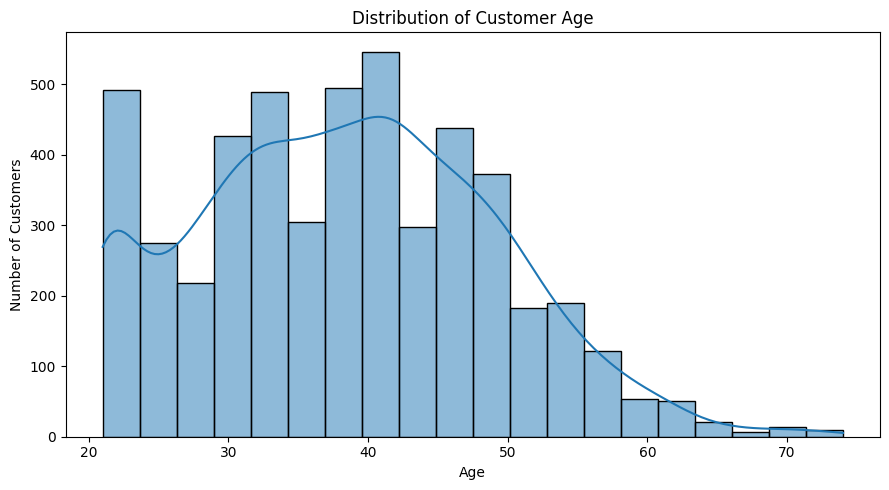

In [43]:
# Summary statistics for customer age
print(customers["age"].describe())

# Age distribution
plt.figure(figsize=(9, 5))

sns.histplot(
    data=customers,
    x="age",
    bins=20,
    kde=True
)

plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

,count
age_group,
21–30,1253
31–40,1615
41–50,1484
51–60,546
61–70,89
71–80,13


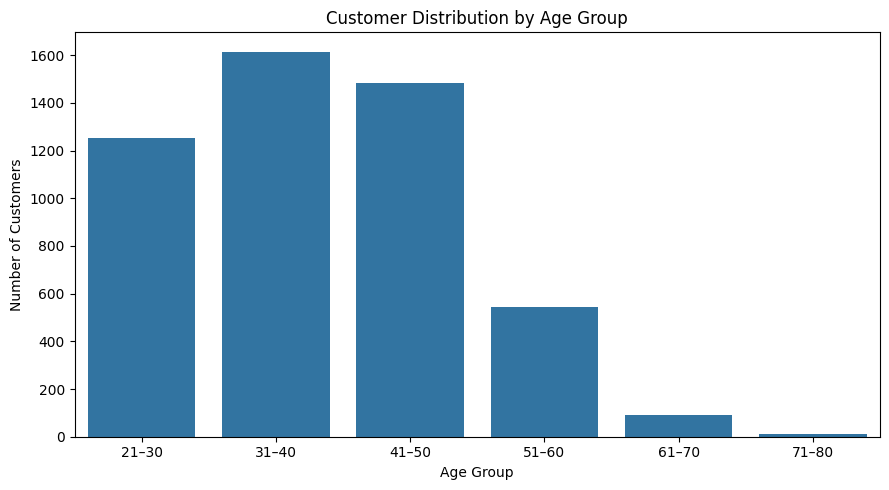

In [44]:
# Create age groups for EDA
age_bins = [20, 30, 40, 50, 60, 70, 80]
age_labels = ["21–30", "31–40", "41–50", "51–60", "61–70", "71–80"]

customers["age_group"] = pd.cut(
    customers["age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

age_group_counts = customers["age_group"].value_counts().sort_index()

display(age_group_counts)

plt.figure(figsize=(9, 5))

sns.countplot(
    data=customers,
    x="age_group",
    order=age_labels
)

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

#### Key Findings

- Customer age ranges from **21 to 74 years**, with a mean age of approximately
  **38.39 years** and a median age of **38 years**.
- The middle 50% of customers are between **30 and 46 years old**.
- The age distribution is concentrated primarily among customers in their
  **30s and 40s**, while the number of customers decreases noticeably at
  higher ages.
- The **31–40 age group** is the largest customer segment with **1,615
  customers**, followed by the **41–50 age group** with **1,484 customers**.
- The **21–30 age group** also represents a substantial portion of the customer
  base with **1,253 customers**.
- Customers above age 50 are comparatively less represented, with **546
  customers aged 51–60**, **89 aged 61–70**, and only **13 aged 71–80**.
- Overall, **4,352 of the 5,000 customers (87.04%) are between 21 and 50 years
  old**, indicating that the customer base is strongly concentrated within
  this age range.

#### EDA Implication

Age shows sufficient variation across the customer population to be considered
a potentially informative characteristic. Its relationship with loan default
will be examined later during bivariate credit risk analysis rather than
drawing conclusions about default risk from the age distribution alone.

### 9.2 Customer Demographic Characteristics

Categorical customer characteristics are examined to understand the demographic
and socioeconomic composition of the customer base.

This analysis focuses on `gender`, `marital_status`, `education`, and
`employment_type`. Frequency distributions and visualizations are used to
identify the dominant categories and determine whether any groups are
substantially under- or over-represented.

In [45]:
# Frequency distribution of key demographic variables

demographic_columns = [
    "gender",
    "marital_status",
    "education",
    "employment_type"
]

for col in demographic_columns:
    print(f"\n{col.upper()}")
    print("-" * 40)

    counts = customers[col].value_counts()
    percentages = customers[col].value_counts(normalize=True).mul(100).round(2)

    summary = pd.DataFrame({
        "Count": counts,
        "Percentage (%)": percentages
    })

    display(summary)


GENDER
----------------------------------------


,Count,Percentage (%)
gender,,
Male,2916,58.32
Female,2084,41.68



MARITAL_STATUS
----------------------------------------


,Count,Percentage (%)
marital_status,,
Married,2689,53.78
Single,1771,35.42
Divorced,324,6.48
Widowed,216,4.32



EDUCATION
----------------------------------------


,Count,Percentage (%)
education,,
Graduate,2141,42.82
Post Graduate,1255,25.10
Diploma,713,14.26
High School,493,9.86
Professional Degree,398,7.96



EMPLOYMENT_TYPE
----------------------------------------


,Count,Percentage (%)
employment_type,,
Salaried,2707,54.14
Self-Employed,1040,20.80
Business Owner,629,12.58
Retired,352,7.04
Unemployed,272,5.44


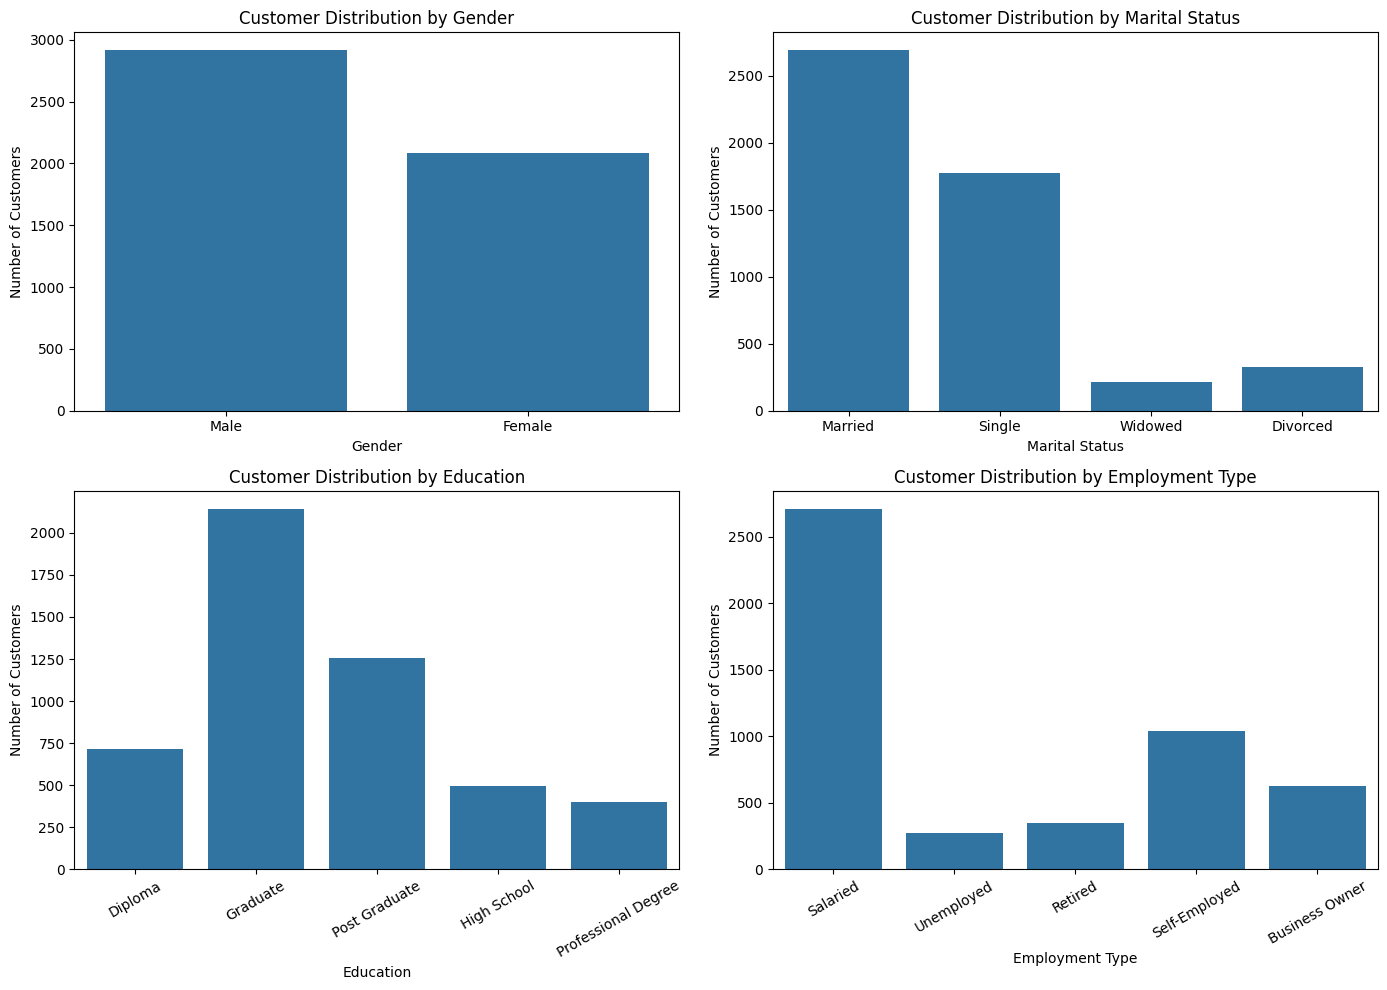

In [46]:
# Visualize customer demographic characteristics

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(
    data=customers,
    x="gender",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Customer Distribution by Gender")
axes[0, 0].set_xlabel("Gender")
axes[0, 0].set_ylabel("Number of Customers")

sns.countplot(
    data=customers,
    x="marital_status",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Customer Distribution by Marital Status")
axes[0, 1].set_xlabel("Marital Status")
axes[0, 1].set_ylabel("Number of Customers")

sns.countplot(
    data=customers,
    x="education",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Customer Distribution by Education")
axes[1, 0].set_xlabel("Education")
axes[1, 0].set_ylabel("Number of Customers")
axes[1, 0].tick_params(axis="x", rotation=30)

sns.countplot(
    data=customers,
    x="employment_type",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Customer Distribution by Employment Type")
axes[1, 1].set_xlabel("Employment Type")
axes[1, 1].set_ylabel("Number of Customers")
axes[1, 1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

#### Key Findings

- The customer base consists of **58.32% male customers (2,916)** and
  **41.68% female customers (2,084)**, indicating a moderate male majority.

- **Married customers form the largest marital-status group**, accounting for
  **53.78% (2,689)** of customers, followed by single customers at
  **35.42% (1,771)**. Divorced and widowed customers represent relatively
  smaller proportions of the customer base.

- In terms of education, **graduates represent the largest group at 42.82%
  (2,141)**, followed by postgraduates at **25.10% (1,255)**. Diploma,
  high-school, and professional-degree customers make up smaller segments.

- **Salaried customers are the dominant employment group**, representing
  **54.14% (2,707)** of the customer base. Self-employed customers account
  for **20.80% (1,040)**, followed by business owners at **12.58% (629)**.

- Retired and unemployed customers represent relatively small portions of the
  dataset, at **7.04%** and **5.44%**, respectively.

#### EDA Implication

The customer population is not evenly distributed across several demographic
categories, particularly employment type, education, and marital status.
These characteristics may provide useful segmentation information; however,
their relationship with loan default cannot be inferred from these
distributions alone and will be evaluated later using default-rate analysis.

### 9.3 Annual Income Distribution

Annual income is an important financial characteristic that reflects a
customer's earning capacity. Understanding its distribution helps identify
the typical income range of customers, the spread of income levels, and
potential high-income observations.

Both a histogram and a boxplot are used to examine the shape of the income
distribution and identify possible skewness or extreme values.

In [47]:
# Descriptive statistics for annual income

print("Annual Income Summary")
print("-" * 40)
print(customers["annual_income"].describe())

Annual Income Summary
----------------------------------------
count    5.000000e+03
mean     5.795758e+05
std      4.225968e+05
min      1.200000e+05
25%      2.941750e+05
50%      4.748000e+05
75%      7.280500e+05
max      4.636900e+06
Name: annual_income, dtype: float64


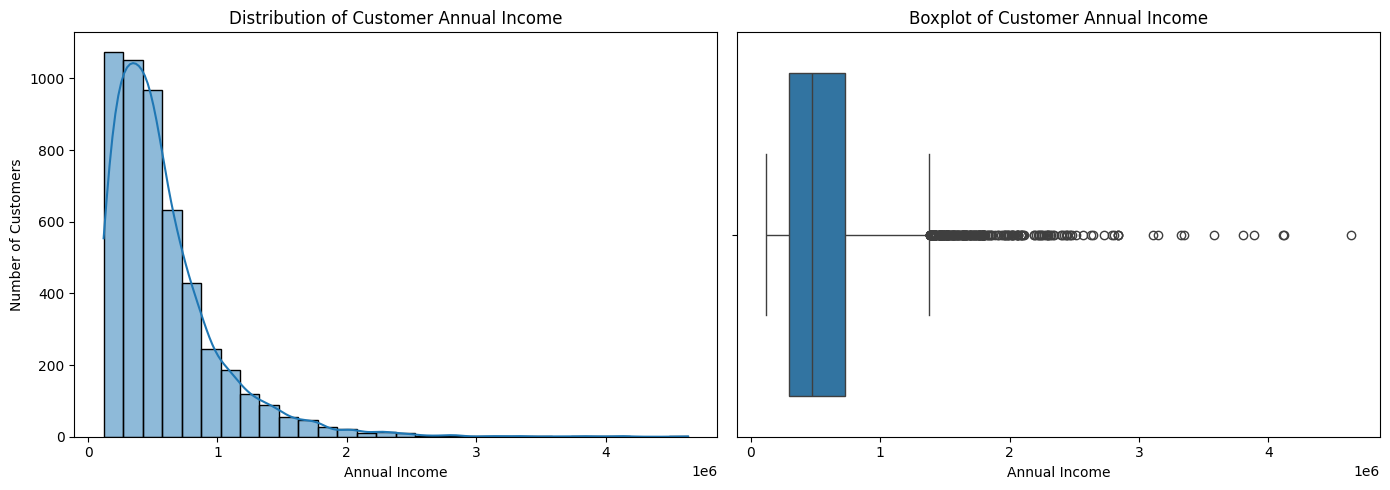

In [48]:
# Distribution of annual income

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
sns.histplot(
    data=customers,
    x="annual_income",
    bins=30,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Distribution of Customer Annual Income")
axes[0].set_xlabel("Annual Income")
axes[0].set_ylabel("Number of Customers")

# Boxplot
sns.boxplot(
    data=customers,
    x="annual_income",
    ax=axes[1]
)

axes[1].set_title("Boxplot of Customer Annual Income")
axes[1].set_xlabel("Annual Income")

plt.tight_layout()
plt.show()

#### Key Findings

- Annual income ranges from **₹120,000 to ₹4,636,900**, showing substantial
  variation in customer earning levels.
- The average annual income is approximately **₹579,576**, while the median
  income is **₹474,800**.
- The middle 50% of customers have annual incomes between approximately
  **₹294,175 and ₹728,050**.
- The histogram shows a **strong right-skewed distribution**, with most
  customers concentrated in the lower-to-middle income ranges and a smaller
  number of customers having substantially higher incomes.
- The mean income is higher than the median, which is consistent with the
  positive skew visible in the distribution.
- The boxplot identifies several observations above the upper whisker,
  representing potentially high-income outliers.
- These observations are not treated as data errors at this stage because
  their values may represent genuine high-income customers.

#### EDA Implication

The strong positive skew and presence of high-income observations may influence
statistical analysis and model behavior. Annual income will therefore be
retained in its original form during EDA, while potential transformations or
robust preprocessing techniques can be considered later during feature
engineering and model development.

### 9.4 Residence and Customer Tenure Analysis

Residence characteristics and customer tenure provide additional information
about the stability and history of customers.

This section examines `residence_type`, `years_at_residence`, and the length of
the customer's relationship with Credora. Customer tenure is derived from
`customer_since` using the common credit-history snapshot date of
30 June 2024.

,Count,Percentage (%)
residence_type,,
Rented,1861,37.22
Owned,1516,30.32
Mortgaged,822,16.44
Family Owned,801,16.02


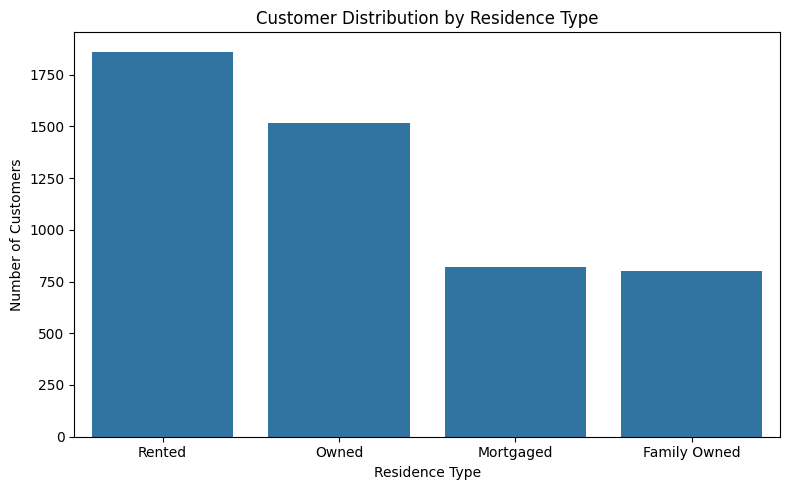

In [49]:
# Residence type distribution

residence_summary = pd.DataFrame({
    "Count": customers["residence_type"].value_counts(),
    "Percentage (%)": customers["residence_type"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
})

display(residence_summary)

plt.figure(figsize=(8, 5))

sns.countplot(
    data=customers,
    x="residence_type",
    order=customers["residence_type"].value_counts().index
)

plt.title("Customer Distribution by Residence Type")
plt.xlabel("Residence Type")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

Years at Residence Summary
----------------------------------------
count    5000.00000
mean        9.94840
std         6.52842
min         0.00000
25%         4.00000
50%         9.00000
75%        15.00000
max        24.00000
Name: years_at_residence, dtype: float64


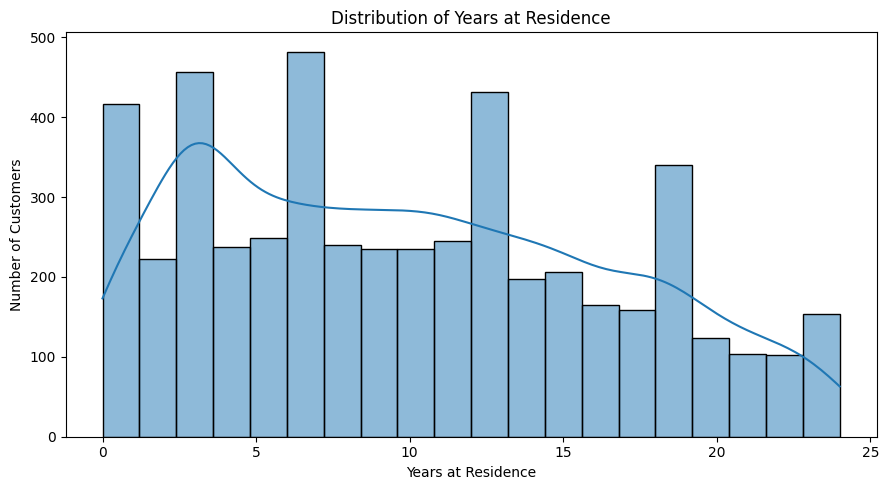

In [50]:
# Years at residence summary

print("Years at Residence Summary")
print("-" * 40)
print(customers["years_at_residence"].describe())

plt.figure(figsize=(9, 5))

sns.histplot(
    data=customers,
    x="years_at_residence",
    bins=20,
    kde=True
)

plt.title("Distribution of Years at Residence")
plt.xlabel("Years at Residence")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [51]:
# Calculate customer tenure as of the dataset snapshot date

snapshot_date = pd.Timestamp("2024-06-30")

customers["customer_tenure_years"] = (
    (snapshot_date - customers["customer_since"]).dt.days / 365.25
)

print("Customer Tenure Summary")
print("-" * 40)
print(customers["customer_tenure_years"].describe())

Customer Tenure Summary
----------------------------------------
count    5000.000000
mean        5.036622
std         3.222647
min         0.000000
25%         2.119097
50%         4.861054
75%         7.752225
max        10.997947
Name: customer_tenure_years, dtype: float64


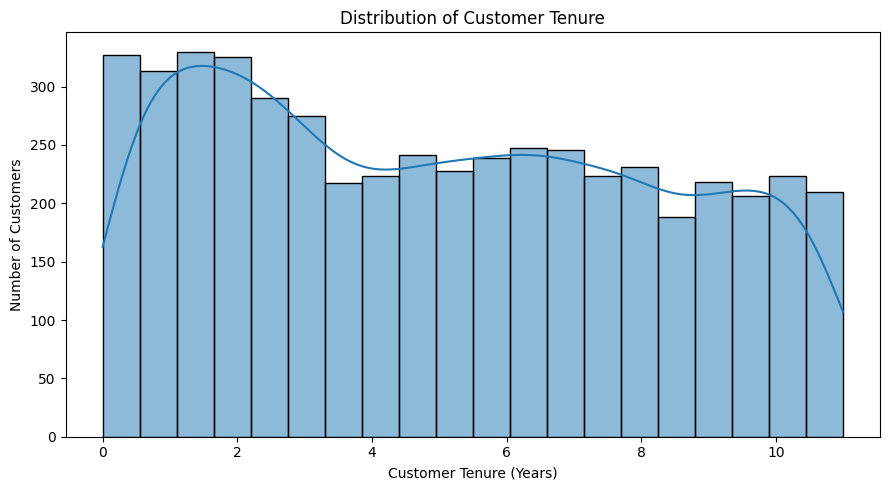

In [52]:
# Customer tenure distribution

plt.figure(figsize=(9, 5))

sns.histplot(
    data=customers,
    x="customer_tenure_years",
    bins=20,
    kde=True
)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Customer Tenure (Years)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

#### Key Findings

- **Rented accommodation** is the most common residence type, representing
  **37.22% (1,861)** of customers, followed by **owned residences** at
  **30.32% (1,516)**.
- Customers living in mortgaged and family-owned residences account for
  **16.44% (822)** and **16.02% (801)** of the customer base, respectively.

- Customers have lived at their current residence for an average of
  approximately **9.95 years**, with a median of **9 years**.
- `years_at_residence` ranges from **0 to 24 years**, indicating considerable
  variation in residential duration across customers.
- The middle 50% of customers have lived at their current residence for
  approximately **4 to 15 years**.

- Customer tenure with Credora ranges from approximately **0 to 11 years**.
  The average customer tenure is approximately **5.04 years**, while the
  median is approximately **4.86 years**.
- The middle 50% of customers have a relationship with Credora ranging from
  approximately **2.12 to 7.75 years**.
- The tenure distribution shows customers across both relatively new and
  long-standing relationships with the institution.

#### EDA Implication

Residence characteristics and customer tenure provide measures of residential
and relationship stability that may contain useful information for credit-risk
assessment. Their actual association with default behavior will be evaluated
later after customer information is linked with the labeled loan records.

## 10. Credit History and Risk Profile Analysis

Credit history variables provide information about a customer's past borrowing
behavior, repayment patterns, credit usage, and existing debt obligations.
These characteristics are particularly important for assessing credit risk.

This section examines credit score, credit utilization, late-payment history,
previous defaults, bankruptcies, credit inquiries, credit limits, and
outstanding debt before their relationship with loan default is analyzed.

### 10.1 Credit Score Distribution

Credit score is examined to understand the overall credit profile of customers.
Descriptive statistics, a histogram, and a boxplot are used to evaluate its
central tendency, spread, distribution, and potentially extreme observations.

In [53]:
# Descriptive statistics for credit score

print("Credit Score Summary")
print("-" * 40)
print(credit["credit_score"].describe())

Credit Score Summary
----------------------------------------
count    5000.00000
mean      648.93440
std        85.40396
min       300.00000
25%       595.00000
50%       652.00000
75%       706.00000
max       900.00000
Name: credit_score, dtype: float64


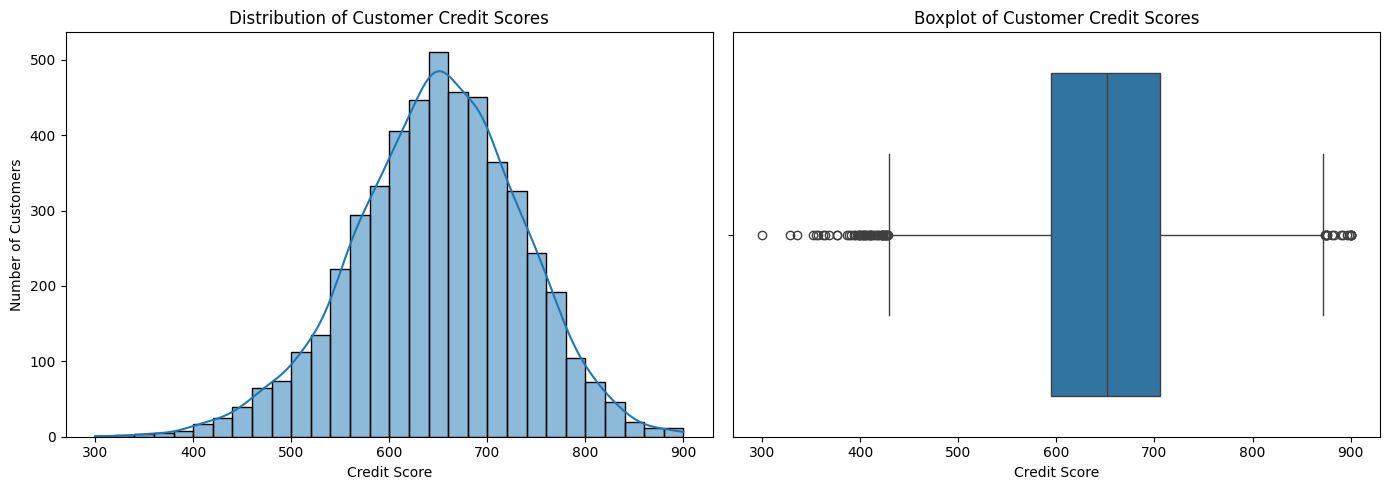

In [54]:
# Credit score distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=credit,
    x="credit_score",
    bins=30,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Distribution of Customer Credit Scores")
axes[0].set_xlabel("Credit Score")
axes[0].set_ylabel("Number of Customers")

sns.boxplot(
    data=credit,
    x="credit_score",
    ax=axes[1]
)

axes[1].set_title("Boxplot of Customer Credit Scores")
axes[1].set_xlabel("Credit Score")

plt.tight_layout()
plt.show()

#### Key Findings

- Credit scores range from **300 to 900**, with an average score of
  approximately **648.93** and a median of **652**.
- The middle 50% of customers have credit scores between **595 and 706**.
- The mean and median are relatively close, indicating that the central
  tendency of the credit-score distribution is fairly balanced.
- The histogram shows that credit scores are concentrated mainly around the
  middle of the observed range, with fewer customers at the very low and very
  high ends.
- The boxplot identifies observations at both extremes of the credit-score
  distribution.
- These extreme observations are retained because there is no evidence from
  the current data-quality checks that they represent erroneous records.

#### EDA Implication

Credit score shows substantial variation across customers and is a potentially
important credit-risk characteristic. However, the distribution alone does not
show whether lower or higher scores are associated with default. That
relationship will be examined later using the labeled loan-default population.

### 10.2 Credit Utilization Analysis

Credit utilization represents the proportion of available credit currently
being used by a customer. Higher utilization may indicate greater dependence
on existing credit facilities.

The distribution of `credit_utilization_ratio` is examined using descriptive
statistics, a histogram, and a boxplot. Its relationship with loan default
will be evaluated later during bivariate risk analysis.

In [55]:
# Descriptive statistics for credit utilization

print("Credit Utilization Ratio Summary")
print("-" * 45)
print(credit["credit_utilization_ratio"].describe())

Credit Utilization Ratio Summary
---------------------------------------------
count    5000.000000
mean        0.368043
std         0.187692
min         0.020000
25%         0.222000
50%         0.353000
75%         0.502000
max         0.990000
Name: credit_utilization_ratio, dtype: float64


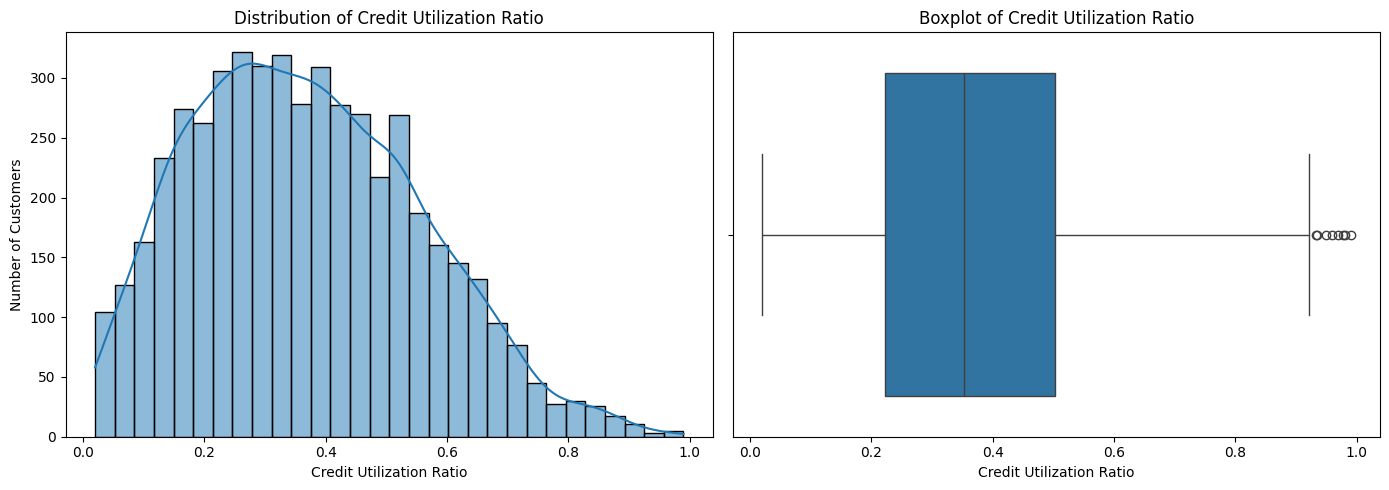

In [56]:
# Credit utilization distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=credit,
    x="credit_utilization_ratio",
    bins=30,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Distribution of Credit Utilization Ratio")
axes[0].set_xlabel("Credit Utilization Ratio")
axes[0].set_ylabel("Number of Customers")

sns.boxplot(
    data=credit,
    x="credit_utilization_ratio",
    ax=axes[1]
)

axes[1].set_title("Boxplot of Credit Utilization Ratio")
axes[1].set_xlabel("Credit Utilization Ratio")

plt.tight_layout()
plt.show()

#### Key Findings

- Credit utilization ranges from **0.02 to 0.99**, with an average utilization
  ratio of approximately **0.368** and a median of **0.353**.
- The middle 50% of customers have credit utilization ratios between
  **0.222 and 0.502**.
- The histogram shows that the distribution is moderately concentrated in the
  lower-to-middle utilization range, with the number of customers generally
  decreasing toward very high utilization levels.
- The mean is slightly higher than the median, and the distribution shows a
  mild positive (right) skew.
- The boxplot identifies a small number of observations near the upper end of
  the utilization range as potential statistical outliers.
- Since all observed utilization ratios fall between **0.02 and 0.99**, these
  high-utilization observations are retained rather than treated as data
  errors.

#### EDA Implication

Credit utilization varies substantially across customers and may provide useful
information about existing credit usage. Its relationship with loan default
will be examined later using the labeled loan population before drawing any
conclusions about its effect on default risk.

### 10.3 Repayment History Analysis

Past repayment behavior provides important information about a customer's
credit history. This section examines the number of 30-day and 90-day late
payments, previous defaults, and bankruptcies recorded for each customer.

Frequency distributions are used to determine how common these repayment
events are within the customer population.

In [57]:
repayment_columns = [
    "num_late_payments_30d",
    "num_late_payments_90d",
    "num_defaults_prior",
    "bankruptcies"
]

for col in repayment_columns:
    print(f"\n{col.upper()}")
    print("-" * 45)

    summary = pd.DataFrame({
        "Count": credit[col].value_counts().sort_index(),
        "Percentage (%)": (
            credit[col]
            .value_counts(normalize=True)
            .sort_index()
            .mul(100)
            .round(2)
        )
    })

    display(summary)


NUM_LATE_PAYMENTS_30D
---------------------------------------------


,Count,Percentage (%)
num_late_payments_30d,,
0,1967,39.34
1,1276,25.52
2,800,16.00
3,512,10.24
4,250,5.00
5,134,2.68
6,48,0.96
7,9,0.18
8,3,0.06



NUM_LATE_PAYMENTS_90D
---------------------------------------------


,Count,Percentage (%)
num_late_payments_90d,,
0,4025,80.50
1,717,14.34
2,202,4.04
3,54,1.08
4,1,0.02
5,1,0.02



NUM_DEFAULTS_PRIOR
---------------------------------------------


,Count,Percentage (%)
num_defaults_prior,,
0,4391,87.82
1,456,9.12
2,112,2.24
3,35,0.70
4,6,0.12



BANKRUPTCIES
---------------------------------------------


,Count,Percentage (%)
bankruptcies,,
0,4991,99.82
1,9,0.18


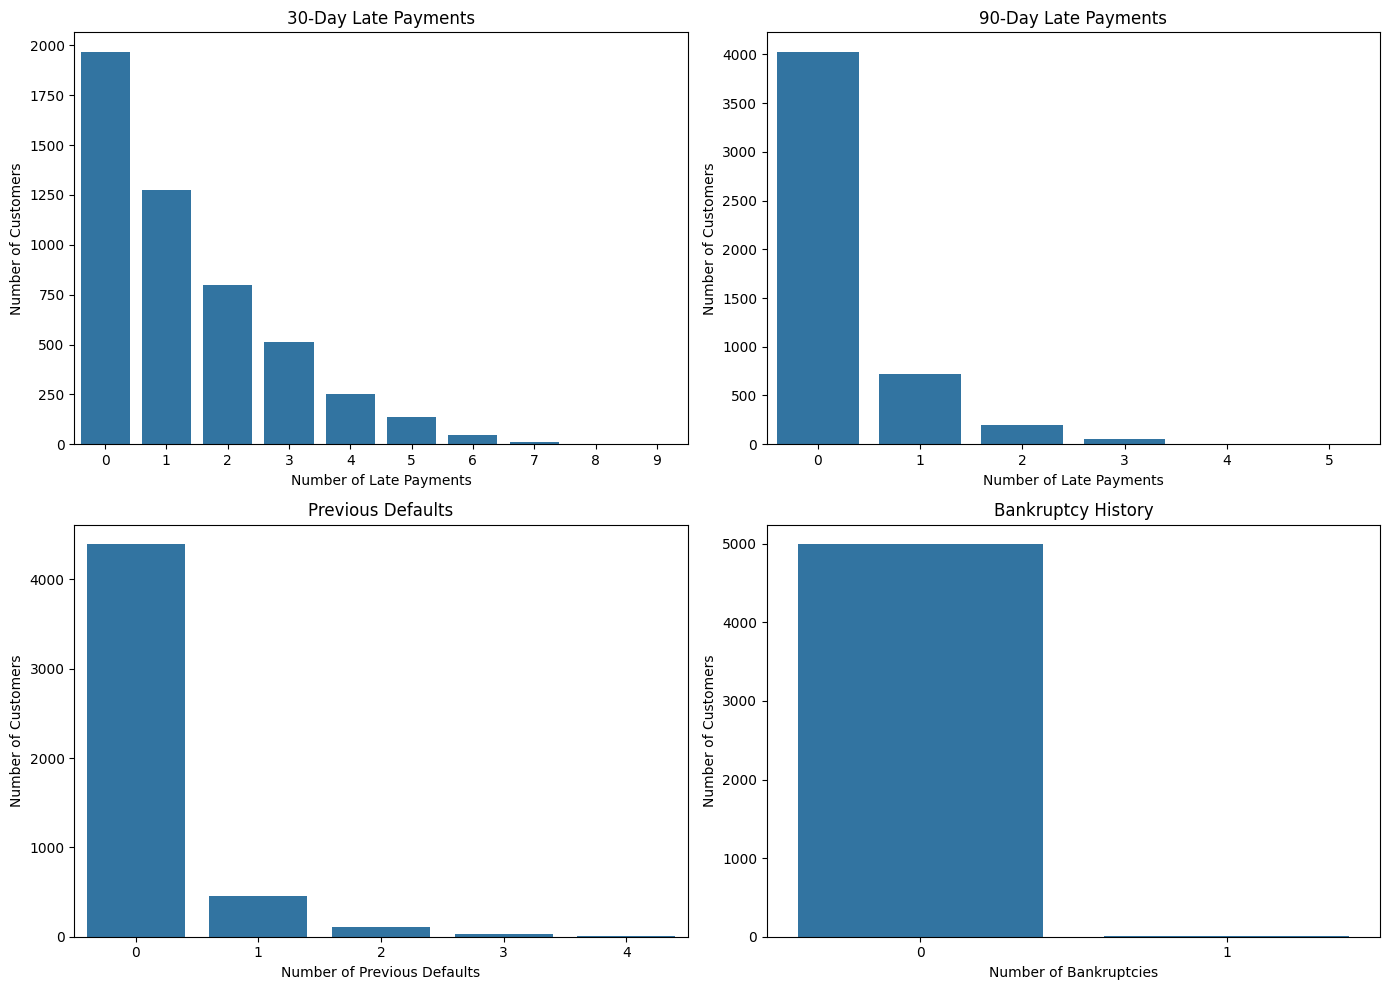

In [58]:
# Visualize repayment history variables

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(
    data=credit,
    x="num_late_payments_30d",
    ax=axes[0, 0]
)
axes[0, 0].set_title("30-Day Late Payments")
axes[0, 0].set_xlabel("Number of Late Payments")
axes[0, 0].set_ylabel("Number of Customers")

sns.countplot(
    data=credit,
    x="num_late_payments_90d",
    ax=axes[0, 1]
)
axes[0, 1].set_title("90-Day Late Payments")
axes[0, 1].set_xlabel("Number of Late Payments")
axes[0, 1].set_ylabel("Number of Customers")

sns.countplot(
    data=credit,
    x="num_defaults_prior",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Previous Defaults")
axes[1, 0].set_xlabel("Number of Previous Defaults")
axes[1, 0].set_ylabel("Number of Customers")

sns.countplot(
    data=credit,
    x="bankruptcies",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Bankruptcy History")
axes[1, 1].set_xlabel("Number of Bankruptcies")
axes[1, 1].set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

#### Key Findings

- **30-day late payments are relatively common** in the customer population.
  While **39.34% (1,967)** of customers have no recorded 30-day late payments,
  **60.66%** have experienced at least one.

- The frequency of 30-day late payments decreases as the number of late-payment
  events increases. Only a very small proportion of customers have more than
  six recorded 30-day late payments.

- **90-day late payments are considerably less common.** A total of
  **80.50% (4,025)** of customers have no recorded 90-day late payments,
  meaning **19.50%** have experienced at least one.

- Most customers have no history of previous default:
  **87.82% (4,391)** have zero prior defaults, while **12.18%** have at least
  one previous default.

- Bankruptcy is extremely rare in the dataset. **99.82% (4,991)** of customers
  have no bankruptcy history, while only **9 customers (0.18%)** have one
  recorded bankruptcy.

- Overall, the repayment-history variables are strongly concentrated toward
  zero, particularly for severe credit events such as 90-day late payments,
  previous defaults, and bankruptcies.

#### EDA Implication

Repayment-history variables capture different levels of past credit difficulty
and may provide useful information for credit-risk modeling. However, the
frequency distributions alone do not establish their relationship with the
current loan-default outcome. Their association with `loan_default` will be
examined later after the credit-history data is linked with the labeled loan
applications.

The strong imbalance in rare events such as bankruptcy should also be
considered during later analysis and modeling.

### 10.4 Credit Inquiries and Open Accounts

Recent credit inquiries and the number of currently open credit accounts
provide additional information about a customer's credit activity.

This section examines the distribution of credit inquiries recorded during
the previous six months and the number of open credit accounts held by
customers.

In [59]:
# Summary statistics for credit activity

print("Credit Inquiries in Last 6 Months")
print("-" * 45)
print(credit["num_credit_inquiries_6m"].describe())

print("\nNumber of Open Accounts")
print("-" * 45)
print(credit["num_open_accounts"].describe())

print("\nCredit Inquiry Frequency")
display(
    credit["num_credit_inquiries_6m"]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

Credit Inquiries in Last 6 Months
---------------------------------------------
count    5000.000000
mean        1.670400
std         1.326694
min         0.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         8.000000
Name: num_credit_inquiries_6m, dtype: float64

Number of Open Accounts
---------------------------------------------
count    5000.000000
mean        3.490400
std         1.848294
min         0.000000
25%         2.000000
50%         3.000000
75%         5.000000
max        14.000000
Name: num_open_accounts, dtype: float64

Credit Inquiry Frequency


,Count
num_credit_inquiries_6m,
0,986
1,1552
2,1276
3,713
4,316
5,113
6,30
7,12
8,2


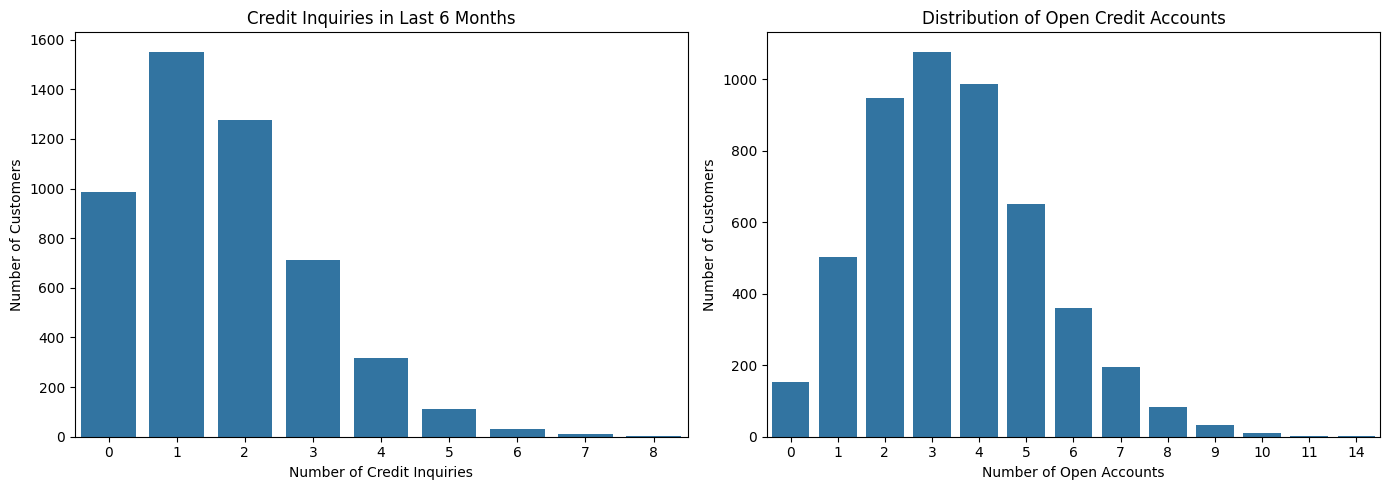

In [60]:
# Visualize credit inquiries and open accounts

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Credit inquiries
sns.countplot(
    data=credit,
    x="num_credit_inquiries_6m",
    ax=axes[0]
)

axes[0].set_title("Credit Inquiries in Last 6 Months")
axes[0].set_xlabel("Number of Credit Inquiries")
axes[0].set_ylabel("Number of Customers")

# Open accounts
sns.countplot(
    data=credit,
    x="num_open_accounts",
    ax=axes[1]
)

axes[1].set_title("Distribution of Open Credit Accounts")
axes[1].set_xlabel("Number of Open Accounts")
axes[1].set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

#### Key Findings

- Customers have between **0 and 8 credit inquiries** during the previous
  six months, with an average of approximately **1.67 inquiries** and a
  median of **1 inquiry**.

- The most common number of recent credit inquiries is **1**, observed for
  **1,552 customers**, followed by **2 inquiries (1,276 customers)** and
  **0 inquiries (986 customers)**.

- The frequency of customers decreases substantially as the number of credit
  inquiries increases. Only a small number of customers have six or more
  inquiries during the six-month period.

- The number of open credit accounts ranges from **0 to 14**, with an average
  of approximately **3.49 accounts** and a median of **3 accounts**.

- The middle 50% of customers have between **2 and 5 open accounts**.

- The open-account distribution is concentrated mainly around **2 to 5
  accounts**, while customers with a large number of open accounts are
  comparatively uncommon.

#### EDA Implication

Credit inquiries and open accounts provide information about the level of
recent credit activity and the extent of customers' existing credit
relationships. Their association with loan default will be evaluated later
using the labeled loan population rather than inferring credit risk directly
from these distributions.

### 10.5 Credit Exposure and Outstanding Debt Analysis

Credit exposure reflects the amount of credit available to a customer and the
amount of debt currently outstanding. These variables help describe the
customer's existing financial obligations and overall use of available credit.

This section examines `total_credit_limit`, `total_outstanding_debt`, and
`oldest_account_age_months`. A derived `debt_to_limit` feature is subsequently
created to measure outstanding debt relative to the customer's total available
credit limit.

In [61]:
# Summary statistics for credit exposure variables

print("Total Credit Limit")
print("-" * 45)
print(credit["total_credit_limit"].describe())

print("\nTotal Outstanding Debt")
print("-" * 45)
print(credit["total_outstanding_debt"].describe())

print("\nOldest Account Age (Months)")
print("-" * 45)
print(credit["oldest_account_age_months"].describe())

Total Credit Limit
---------------------------------------------
count    5.000000e+03
mean     3.193644e+05
std      2.769357e+05
min      2.500000e+04
25%      1.380000e+05
50%      2.435000e+05
75%      4.070000e+05
max      3.651000e+06
Name: total_credit_limit, dtype: float64

Total Outstanding Debt
---------------------------------------------
count    5.000000e+03
mean     1.095843e+05
std      1.116656e+05
min      2.500000e+03
25%      4.040000e+04
50%      7.530000e+04
75%      1.396000e+05
max      1.682000e+06
Name: total_outstanding_debt, dtype: float64

Oldest Account Age (Months)
---------------------------------------------
count    5000.000000
mean      192.691600
std       122.504552
min         6.000000
25%        96.000000
50%       190.000000
75%       281.000000
max       480.000000
Name: oldest_account_age_months, dtype: float64


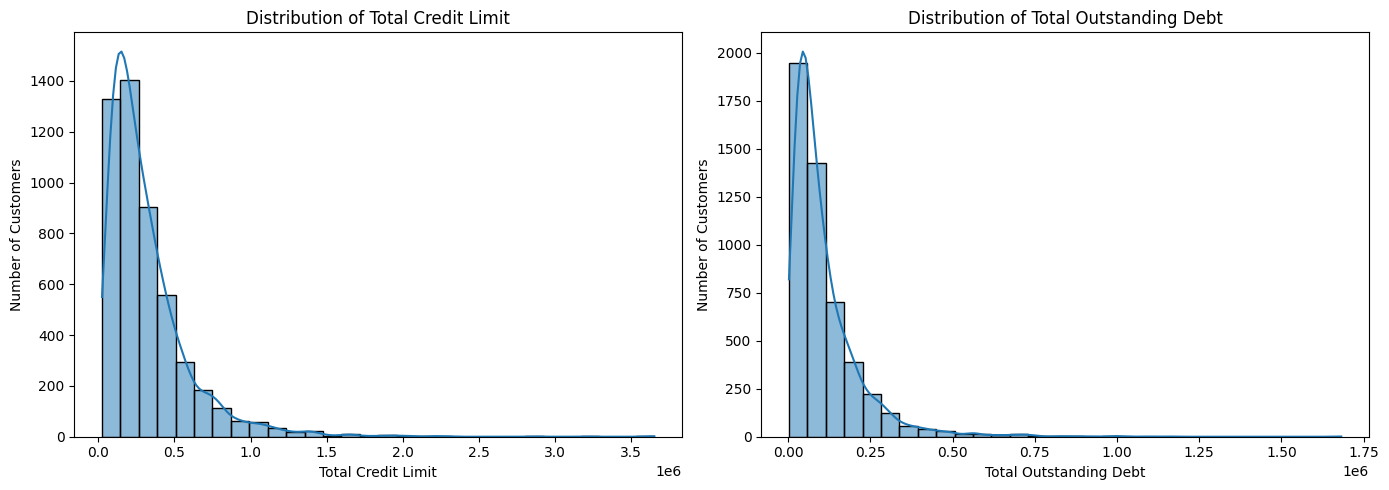

In [62]:
# Distribution of total credit limit and outstanding debt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=credit,
    x="total_credit_limit",
    bins=30,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Distribution of Total Credit Limit")
axes[0].set_xlabel("Total Credit Limit")
axes[0].set_ylabel("Number of Customers")

sns.histplot(
    data=credit,
    x="total_outstanding_debt",
    bins=30,
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Distribution of Total Outstanding Debt")
axes[1].set_xlabel("Total Outstanding Debt")
axes[1].set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

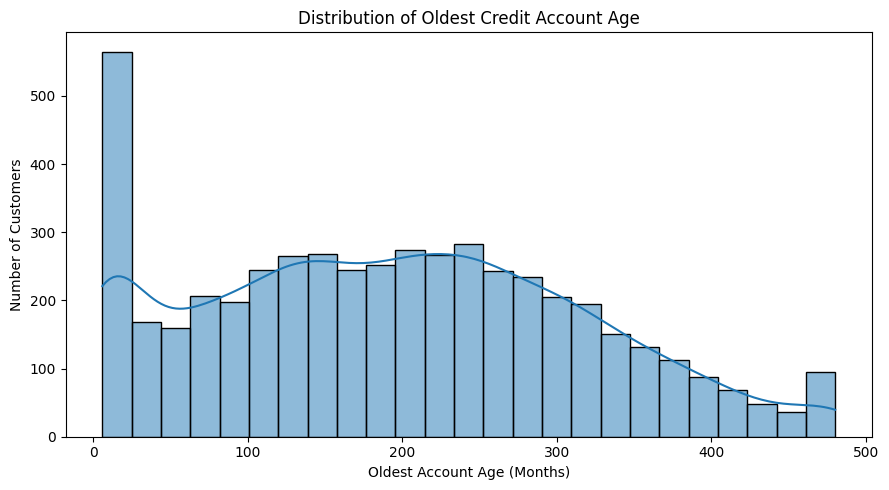

In [63]:
# Distribution of oldest credit account age

plt.figure(figsize=(9, 5))

sns.histplot(
    data=credit,
    x="oldest_account_age_months",
    bins=25,
    kde=True
)

plt.title("Distribution of Oldest Credit Account Age")
plt.xlabel("Oldest Account Age (Months)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

#### Key Findings

- Total credit limits range from **25,000 to 3,651,000**, with an average of
  approximately **319,364** and a median of **243,500**.
- The middle 50% of customers have total credit limits between approximately
  **138,000 and 407,000**.
- The credit-limit distribution is strongly right-skewed. Most customers have
  comparatively lower credit limits, while a smaller number of customers have
  substantially higher limits.

- Total outstanding debt ranges from **2,500 to 1,682,000**, with an average
  of approximately **109,584** and a median of **75,300**.
- The middle 50% of customers have outstanding debt between approximately
  **40,400 and 139,600**.
- Outstanding debt is also strongly right-skewed, with relatively few
  customers accounting for very high debt values.

- The age of the oldest credit account ranges from **6 to 480 months**.
  The average is approximately **192.69 months**, while the median is
  **190 months**.
- The middle 50% of customers have an oldest-account age between
  **96 and 281 months**, indicating considerable variation in the length of
  customers' credit histories.

#### EDA Implication

Credit limit and outstanding debt vary substantially across customers and both
show strong positive skewness. These distributions should be considered during
later preprocessing and modeling.

The oldest-account-age variable captures the length of a customer's established
credit history and may provide additional information for credit-risk
assessment. Its relationship with `loan_default` will be evaluated later using
the labeled loan population.

### 10.6 Debt-to-Limit Ratio

Absolute debt alone does not indicate how heavily a customer is using their
available credit capacity. Therefore, a derived `debt_to_limit` feature is
created by dividing total outstanding debt by total credit limit.

A higher value represents a larger outstanding debt balance relative to the
customer's available credit limit.

In [64]:
# Create debt-to-limit ratio

credit["debt_to_limit"] = (
    credit["total_outstanding_debt"] /
    credit["total_credit_limit"]
)

print("Debt-to-Limit Ratio Summary")
print("-" * 45)
print(credit["debt_to_limit"].describe())

print("\nNumber of ratios greater than 1:")
print((credit["debt_to_limit"] > 1).sum())

print("\nNumber of missing values:")
print(credit["debt_to_limit"].isna().sum())

print("\nNumber of infinite values:")
print(np.isinf(credit["debt_to_limit"]).sum())

Debt-to-Limit Ratio Summary
---------------------------------------------
count    5000.000000
mean        0.368042
std         0.187697
min         0.019718
25%         0.221962
50%         0.353032
75%         0.502025
max         0.989939
Name: debt_to_limit, dtype: float64

Number of ratios greater than 1:
0

Number of missing values:
0

Number of infinite values:
0


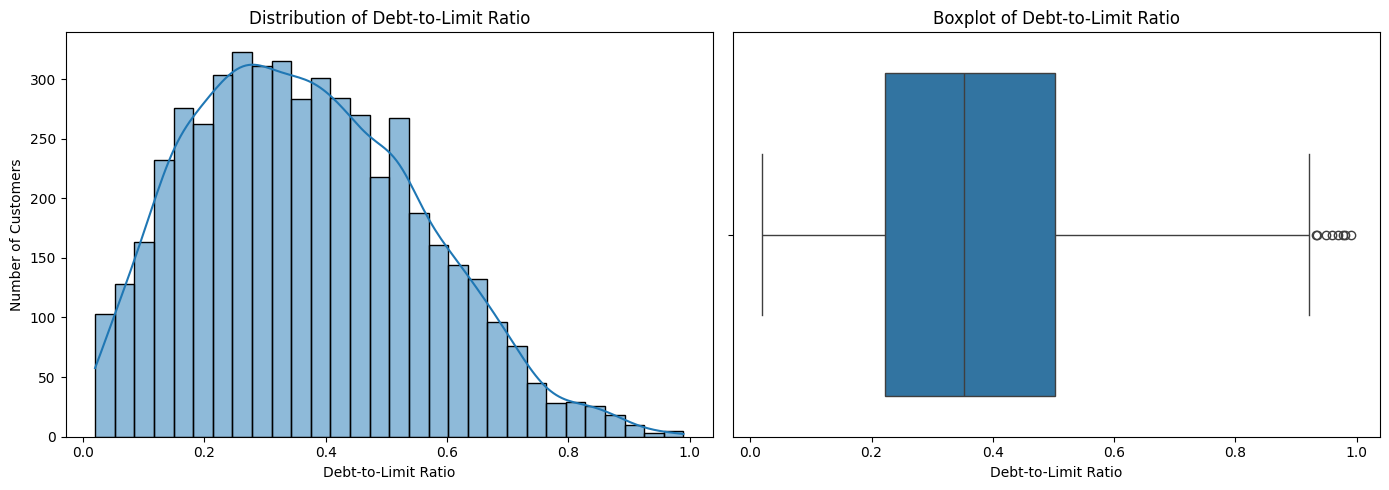

In [65]:
# Distribution of debt-to-limit ratio

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=credit,
    x="debt_to_limit",
    bins=30,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Distribution of Debt-to-Limit Ratio")
axes[0].set_xlabel("Debt-to-Limit Ratio")
axes[0].set_ylabel("Number of Customers")

sns.boxplot(
    data=credit,
    x="debt_to_limit",
    ax=axes[1]
)

axes[1].set_title("Boxplot of Debt-to-Limit Ratio")
axes[1].set_xlabel("Debt-to-Limit Ratio")

plt.tight_layout()
plt.show()

#### Key Findings

- The derived `debt_to_limit` ratio ranges from approximately **0.020 to
  0.990**, with an average of **0.368** and a median of **0.353**.
- The middle 50% of customers have debt-to-limit ratios between approximately
  **0.222 and 0.502**.
- The distribution is concentrated primarily in the lower-to-middle range,
  with relatively fewer customers having very high debt-to-limit ratios.
- The mean is slightly higher than the median, and the distribution shows a
  mild positive (right) skew.
- The boxplot identifies a small number of observations near the upper end of
  the distribution.
- No customer has a debt-to-limit ratio greater than **1**, indicating that
  outstanding debt does not exceed the recorded total credit limit in this
  dataset.
- The engineered feature contains **no missing or infinite values**, confirming
  that the ratio was calculated successfully for all 5,000 customers.

#### EDA Implication

The `debt_to_limit` feature provides a normalized measure of existing debt
exposure by considering outstanding debt relative to available credit capacity.

Its distribution appears very similar to the existing
`credit_utilization_ratio`. The relationship between these two variables will
therefore be examined during correlation and multivariate analysis to determine
whether they contain highly overlapping information before model development.

### 10.7 Correlation Analysis of Credit Variables

After examining individual credit-history variables, correlation analysis is
performed to identify relationships among numerical credit characteristics.

This analysis helps detect strongly related variables and potential
multicollinearity before model development. Particular attention is given to
the relationship between the engineered `debt_to_limit` feature and the
existing `credit_utilization_ratio`.

In [66]:
# Compare credit utilization with the engineered debt-to-limit ratio

comparison = credit[
    [
        "credit_utilization_ratio",
        "debt_to_limit",
        "total_credit_limit",
        "total_outstanding_debt"
    ]
].corr()

display(comparison)

print(
    "\nCorrelation between Credit Utilization Ratio and Debt-to-Limit Ratio:"
)
print(
    credit["credit_utilization_ratio"].corr(
        credit["debt_to_limit"]
    )
)

,credit_utilization_ratio,debt_to_limit,total_credit_limit,total_outstanding_debt
credit_utilization_ratio,1.000000,0.999999,-0.153081,0.402923
debt_to_limit,0.999999,1.000000,-0.153071,0.402923
total_credit_limit,-0.153081,-0.153071,1.000000,0.711594
total_outstanding_debt,0.402923,0.402923,0.711594,1.000000



Correlation between Credit Utilization Ratio and Debt-to-Limit Ratio:
0.9999993083083719


#### Key Findings

- `credit_utilization_ratio` and the engineered `debt_to_limit` feature have
  an almost perfect positive correlation of approximately **1.00 (0.999999)**.
- This indicates that the two variables contain almost identical information
  in the current dataset.
- `total_credit_limit` and `total_outstanding_debt` show a moderately strong
  positive correlation of approximately **0.712**.
- `total_outstanding_debt` has a moderate positive correlation of approximately
  **0.403** with both credit utilization and debt-to-limit ratio.
- `total_credit_limit` shows a weak negative correlation of approximately
  **-0.153** with the utilization-based variables.

#### Modeling Consideration

Because `credit_utilization_ratio` and `debt_to_limit` are nearly perfectly
correlated, including both may introduce redundant information into the
model. This will be considered during feature selection before model training.

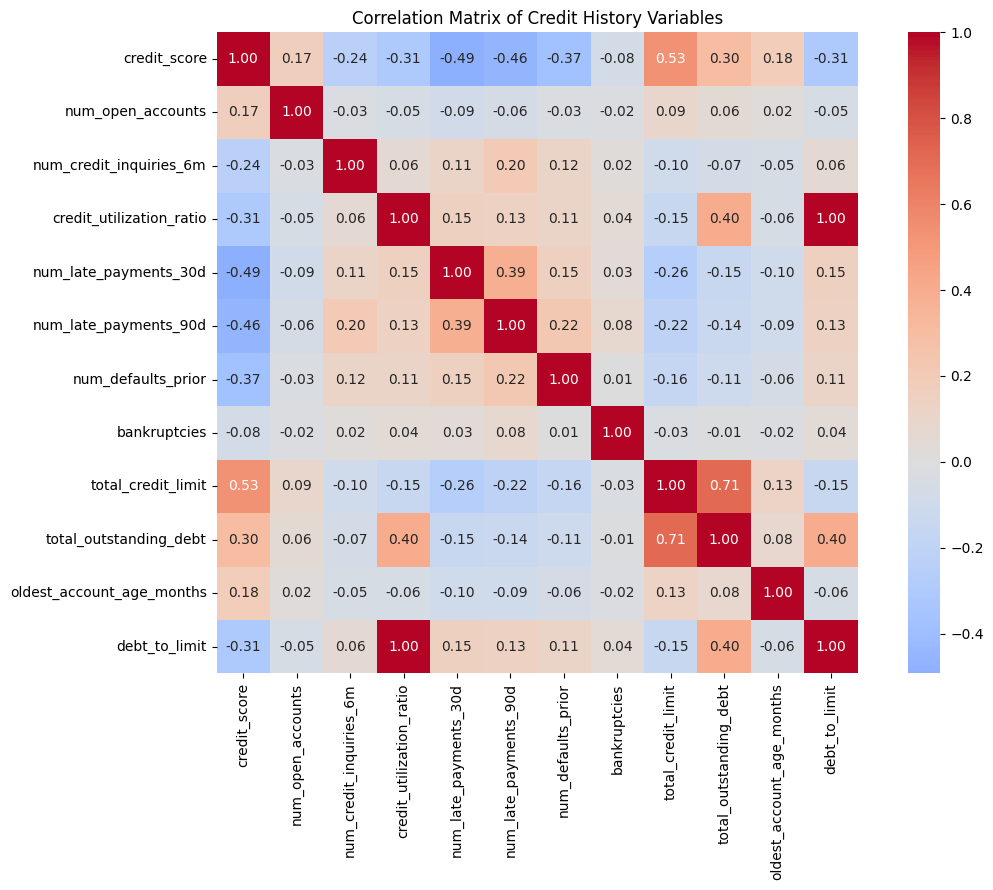

In [67]:
# Select numerical credit-risk variables for correlation analysis

credit_corr_columns = [
    "credit_score",
    "num_open_accounts",
    "num_credit_inquiries_6m",
    "credit_utilization_ratio",
    "num_late_payments_30d",
    "num_late_payments_90d",
    "num_defaults_prior",
    "bankruptcies",
    "total_credit_limit",
    "total_outstanding_debt",
    "oldest_account_age_months",
    "debt_to_limit"
]

credit_corr = credit[credit_corr_columns].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    credit_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Matrix of Credit History Variables")
plt.tight_layout()
plt.show()

#### Key Findings

- The strongest correlation is observed between `credit_utilization_ratio` and
  the engineered `debt_to_limit` feature, with a correlation of approximately
  **1.00**. This confirms that the two variables contain almost identical
  information in this dataset.

- `total_credit_limit` and `total_outstanding_debt` show a strong positive
  correlation of approximately **0.71**, indicating that customers with higher
  overall credit limits also tend to have higher absolute outstanding debt.

- `credit_score` has a moderate positive correlation of approximately **0.53**
  with `total_credit_limit`.

- Credit score is negatively associated with repayment difficulties.
  Correlations of approximately **-0.49** and **-0.46** are observed with
  30-day and 90-day late payments, respectively.

- `credit_score` also shows a negative correlation of approximately **-0.37**
  with previous defaults and approximately **-0.31** with both
  `credit_utilization_ratio` and `debt_to_limit`.

- The number of 30-day and 90-day late payments has a moderate positive
  correlation of approximately **0.39**, suggesting some relationship between
  the two forms of repayment delinquency.

- Most other credit-history variables show weak linear correlations, indicating
  that they may capture different aspects of customer credit behavior.

#### Modeling Consideration

The near-perfect correlation between `credit_utilization_ratio` and
`debt_to_limit` indicates substantial feature redundancy. Including both may
introduce unnecessary multicollinearity, particularly for linear models such
as Logistic Regression.

A final decision on which variable to retain will therefore be made during
feature selection before model training. No variable is removed at the EDA
stage.

## 11. Loan Application Analysis

The loan application dataset contains information about customers' loan
requests, loan characteristics, financial obligations, approval decisions,
disbursement status, and observed loan-default outcomes.

This section explores the characteristics of loan applications before examining
how application-level and customer-level factors are associated with default.

### 11.1 Loan Type and Loan Purpose Distribution

Loan type and loan purpose describe the nature and intended use of the requested
credit. Their distributions are examined to understand the composition of the
loan portfolio and identify the most common categories of borrowing.

In [68]:
# Loan type distribution

loan_type_summary = pd.DataFrame({
    "Count": loans["loan_type"].value_counts(),
    "Percentage (%)": (
        loans["loan_type"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
})

print("LOAN TYPE")
print("-" * 45)
display(loan_type_summary)


# Loan purpose distribution

loan_purpose_summary = pd.DataFrame({
    "Count": loans["loan_purpose"].value_counts(),
    "Percentage (%)": (
        loans["loan_purpose"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
})

print("\nLOAN PURPOSE")
print("-" * 45)
display(loan_purpose_summary)

LOAN TYPE
---------------------------------------------


,Count,Percentage (%)
loan_type,,
Personal,2500,33.33
Auto,1375,18.33
Home,1252,16.69
Business,1038,13.84
Education,727,9.69
Gold,608,8.11



LOAN PURPOSE
---------------------------------------------


,Count,Percentage (%)
loan_purpose,,
Gold Loan,608,8.11
Medical Emergency,531,7.08
Travel,530,7.07
Home Renovation,487,6.49
Wedding,483,6.44
Two Wheeler,474,6.32
Debt Consolidation,469,6.25
New Car,464,6.19
Used Car,437,5.83


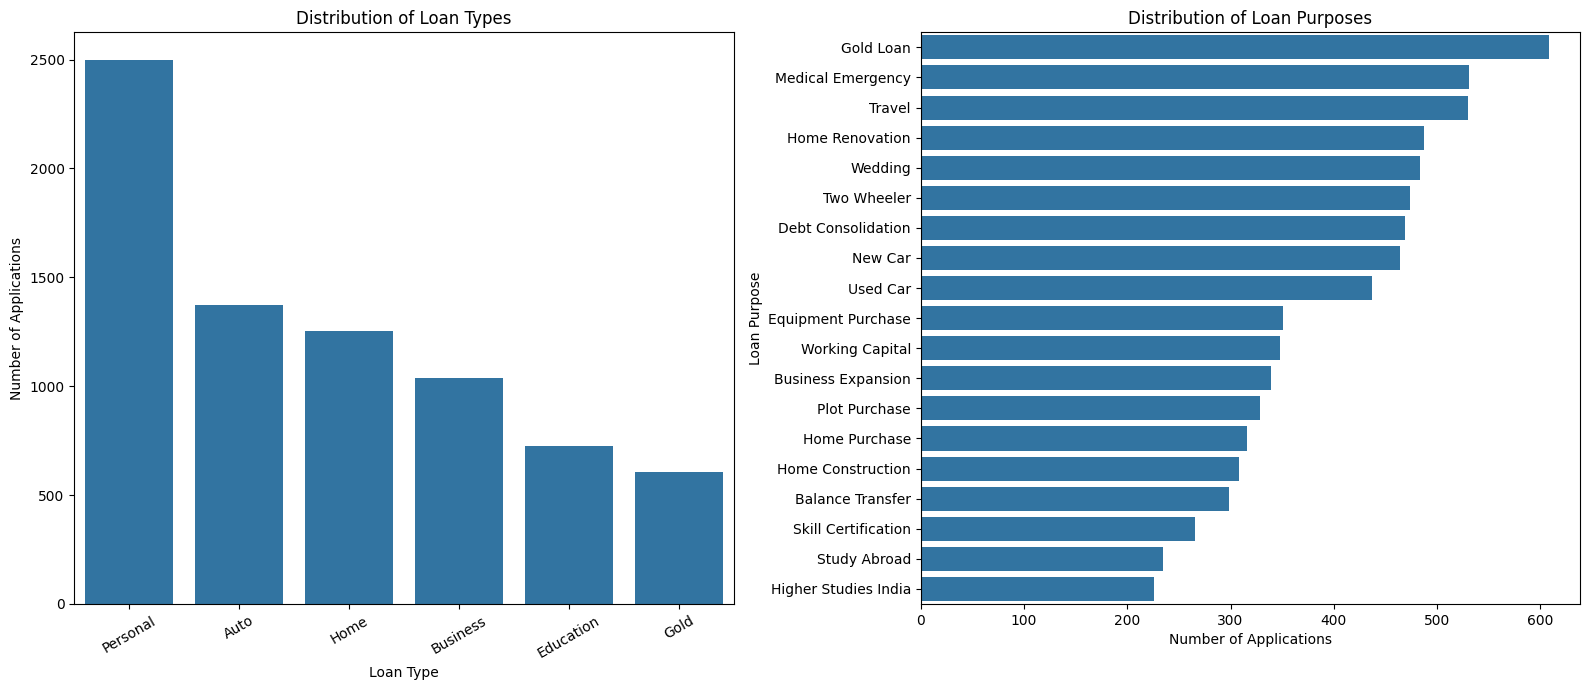

In [69]:
# Visualize loan type and loan purpose distributions

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Loan type
loan_type_order = loans["loan_type"].value_counts().index

sns.countplot(
    data=loans,
    x="loan_type",
    order=loan_type_order,
    ax=axes[0]
)

axes[0].set_title("Distribution of Loan Types")
axes[0].set_xlabel("Loan Type")
axes[0].set_ylabel("Number of Applications")
axes[0].tick_params(axis="x", rotation=30)


# Loan purpose
loan_purpose_order = loans["loan_purpose"].value_counts().index

sns.countplot(
    data=loans,
    y="loan_purpose",
    order=loan_purpose_order,
    ax=axes[1]
)

axes[1].set_title("Distribution of Loan Purposes")
axes[1].set_xlabel("Number of Applications")
axes[1].set_ylabel("Loan Purpose")

plt.tight_layout()
plt.show()

#### Key Findings

- **Personal loans** are the most common loan type, accounting for **2,500 applications (33.33%)**, making them the largest segment of the loan portfolio.
- Auto loans represent **18.33%** of applications, followed by Home loans at **16.69%** and Business loans at **13.84%**.
- Education (**9.69%**) and Gold (**8.11%**) loans form comparatively smaller portions of the application portfolio.
- Loan purposes are more widely distributed across multiple categories, with no single purpose dominating the dataset.
- **Gold Loan** is the most frequent individual loan purpose with **608 applications (8.11%)**, followed by Medical Emergency (**7.08%**) and Travel (**7.07%**).
- Higher Studies India (**3.01%**) and Study Abroad (**3.13%**) are among the least frequent loan purposes.
- Overall, the portfolio contains a diverse mix of borrowing requirements, while Personal loans represent the largest loan-type category.

### 11.2 Requested Loan Amount Distribution

The requested loan amount represents the amount of credit requested by each
applicant. Analyzing its distribution helps identify the typical loan size,
variation across applications, and the presence of unusually large loan
requests.

Requested Loan Amount Summary
---------------------------------------------
count    7.500000e+03
mean     2.368134e+06
std      2.698808e+06
min      3.100000e+04
25%      6.200000e+05
50%      1.288000e+06
75%      2.873750e+06
max      1.200000e+07
Name: requested_amount, dtype: float64


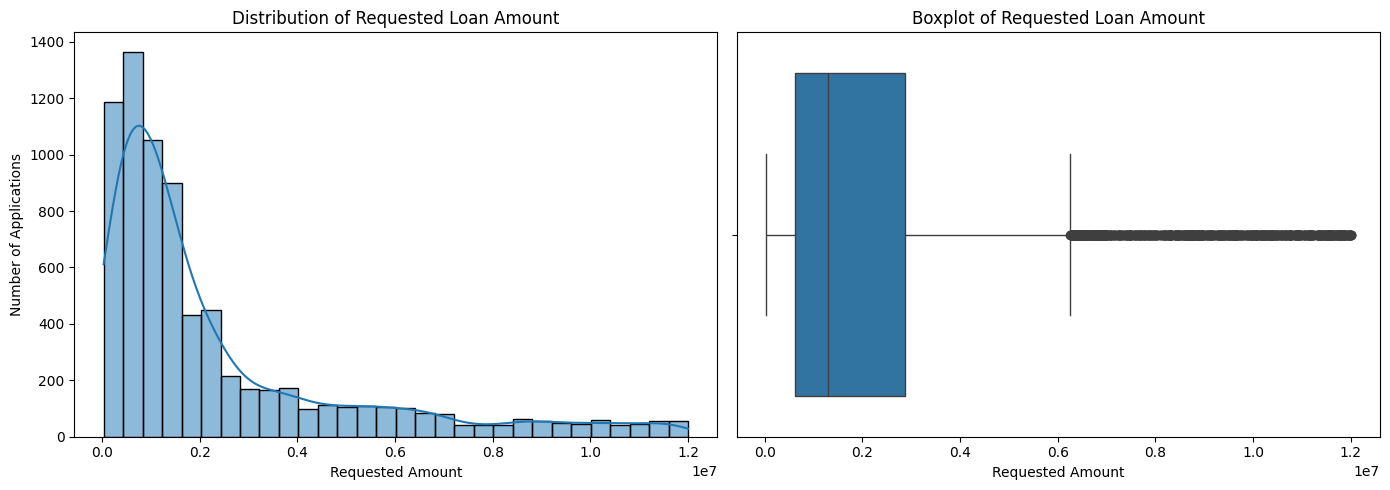

In [70]:
print("Requested Loan Amount Summary")
print("-" * 45)
print(loans["requested_amount"].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=loans,
    x="requested_amount",
    bins=30,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Distribution of Requested Loan Amount")
axes[0].set_xlabel("Requested Amount")
axes[0].set_ylabel("Number of Applications")

sns.boxplot(
    data=loans,
    x="requested_amount",
    ax=axes[1]
)

axes[1].set_title("Boxplot of Requested Loan Amount")
axes[1].set_xlabel("Requested Amount")

plt.tight_layout()
plt.show()

#### Key Findings

- The requested loan amount varies substantially across the 7,500 applications,
  ranging from **₹31,000 to ₹12,000,000 (₹1.2 crore)**.

- The median requested amount is approximately **₹1.29 million (₹12.88 lakh)**,
  while the mean is considerably higher at approximately
  **₹2.37 million (₹23.68 lakh)**.

- The mean being substantially higher than the median indicates that the
  requested loan amount distribution is **positively (right) skewed**.

- Approximately 50% of applications have requested amounts between
  **₹620,000 and ₹2.87 million**.

- The histogram confirms that most applications are concentrated toward lower
  loan amounts, while a smaller number of applications involve substantially
  larger amounts.

- The boxplot identifies numerous high-value observations beyond the upper
  whisker. These values will not be removed automatically because they may
  represent legitimate large loan requests rather than data-entry errors.

#### Modeling Consideration

The strong right-skew and presence of high-value observations should be
considered during preprocessing and model development. Any transformation or
outlier treatment will be evaluated later rather than modifying the original
data during EDA.

### 11.3 Loan Term and Interest Rate

Loan term represents the repayment duration of the requested loan, while the
interest rate represents the borrowing cost associated with the application.

Their distributions are examined to understand the range of financing terms
present in the loan portfolio and identify any unusual values.

In [71]:
print("Loan Term Summary")
print("-" * 45)
print(loans["loan_term_months"].describe())

print("\nInterest Rate Summary")
print("-" * 45)
print(loans["interest_rate"].describe())

print("\nLoan Term Frequency")
print("-" * 45)
print(loans["loan_term_months"].value_counts().sort_index())

Loan Term Summary
---------------------------------------------
count    7500.00000
mean       50.51680
std        40.37292
min        12.00000
25%        24.00000
50%        36.00000
75%        60.00000
max       240.00000
Name: loan_term_months, dtype: float64

Interest Rate Summary
---------------------------------------------
count    7500.000000
mean       13.744532
std         4.124718
min         8.010000
25%        10.290000
50%        12.740000
75%        16.590000
max        24.000000
Name: interest_rate, dtype: float64

Loan Term Frequency
---------------------------------------------
loan_term_months
12     1259
24     1299
36     1219
48     1106
60     1034
84     1100
120     221
180     137
240     125
Name: count, dtype: int64


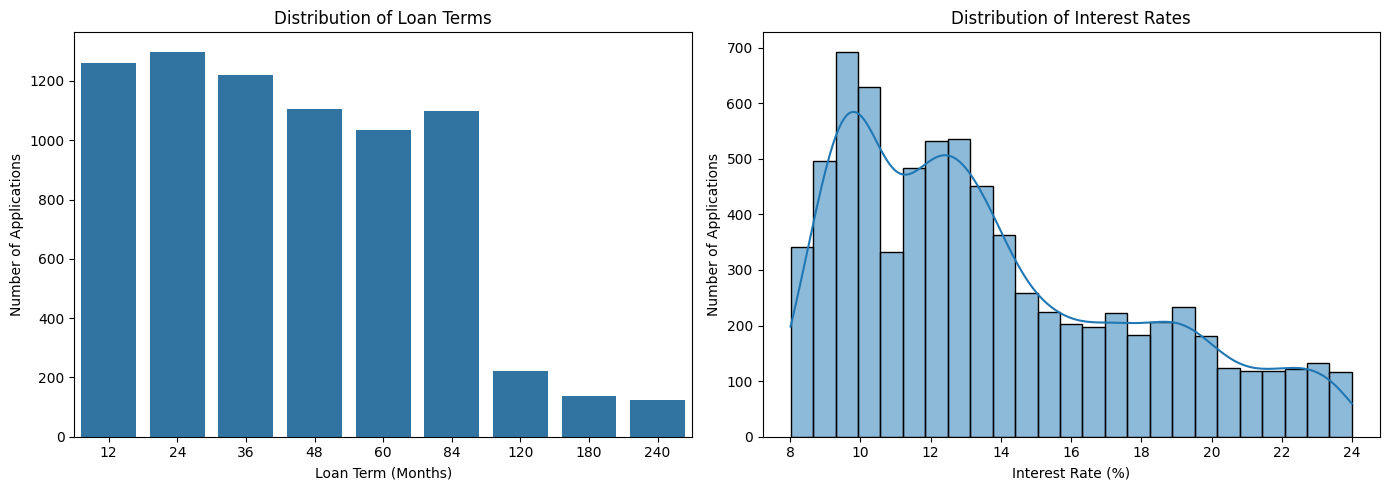

In [72]:
# Loan term and interest rate visualizations

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loan term distribution
term_order = sorted(loans["loan_term_months"].unique())

sns.countplot(
    data=loans,
    x="loan_term_months",
    order=term_order,
    ax=axes[0]
)

axes[0].set_title("Distribution of Loan Terms")
axes[0].set_xlabel("Loan Term (Months)")
axes[0].set_ylabel("Number of Applications")


# Interest rate distribution
sns.histplot(
    data=loans,
    x="interest_rate",
    bins=25,
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Distribution of Interest Rates")
axes[1].set_xlabel("Interest Rate (%)")
axes[1].set_ylabel("Number of Applications")

plt.tight_layout()
plt.show()

#### Key Findings

- Loan terms range from **12 to 240 months**, with a median repayment period of
  **36 months** and an average of approximately **50.52 months**.

- Most loan applications have repayment periods between **12 and 84 months**.
  The **24-month term is the most frequent**, with 1,299 applications, followed
  closely by 12-month and 36-month terms.

- Long-term loans of **120, 180, and 240 months** are substantially less common,
  indicating that the majority of the portfolio consists of short- to
  medium-term borrowing.

- Interest rates range from **8.01% to 24.00%**, with a median of **12.74%**
  and an average of approximately **13.74%**.

- The interest-rate distribution is concentrated more heavily at lower and
  moderate rates, particularly around the 9%–14% range, while progressively
  fewer applications occur at higher interest rates.

- The variation in loan terms and interest rates suggests that borrowers in
  the dataset are offered different financing conditions, which may be
  relevant when examining credit risk and default behavior later in the
  analysis.

### 11.4 Applicant Income and Existing EMI

Applicant monthly income represents the borrower's reported monthly earnings,
while existing EMI represents the monthly repayment obligations already being
serviced by the applicant.

Analyzing these variables helps assess the financial capacity and existing debt
burden of loan applicants before examining the debt-to-income ratio.

In [73]:
print("Applicant Monthly Income Summary")
print("-" * 45)
print(loans["applicant_monthly_income"].describe())

print("\nExisting EMI Summary")
print("-" * 45)
print(loans["existing_emi"].describe())

print("\nApplicants with Zero Existing EMI:")
print((loans["existing_emi"] == 0).sum())

print("\nPercentage with Zero Existing EMI:")
print(
    round(
        (loans["existing_emi"] == 0).mean() * 100,
        2
    ),
    "%"
)

Applicant Monthly Income Summary
---------------------------------------------
count      7500.000000
mean      48526.733333
std       35707.059254
min       10000.000000
25%       25275.000000
50%       39900.000000
75%       60400.000000
max      386400.000000
Name: applicant_monthly_income, dtype: float64

Existing EMI Summary
---------------------------------------------
count      7500.000000
mean       8395.506667
std        8885.046334
min           0.000000
25%        2700.000000
50%        5900.000000
75%       11000.000000
max      108200.000000
Name: existing_emi, dtype: float64

Applicants with Zero Existing EMI:
34

Percentage with Zero Existing EMI:
0.45 %


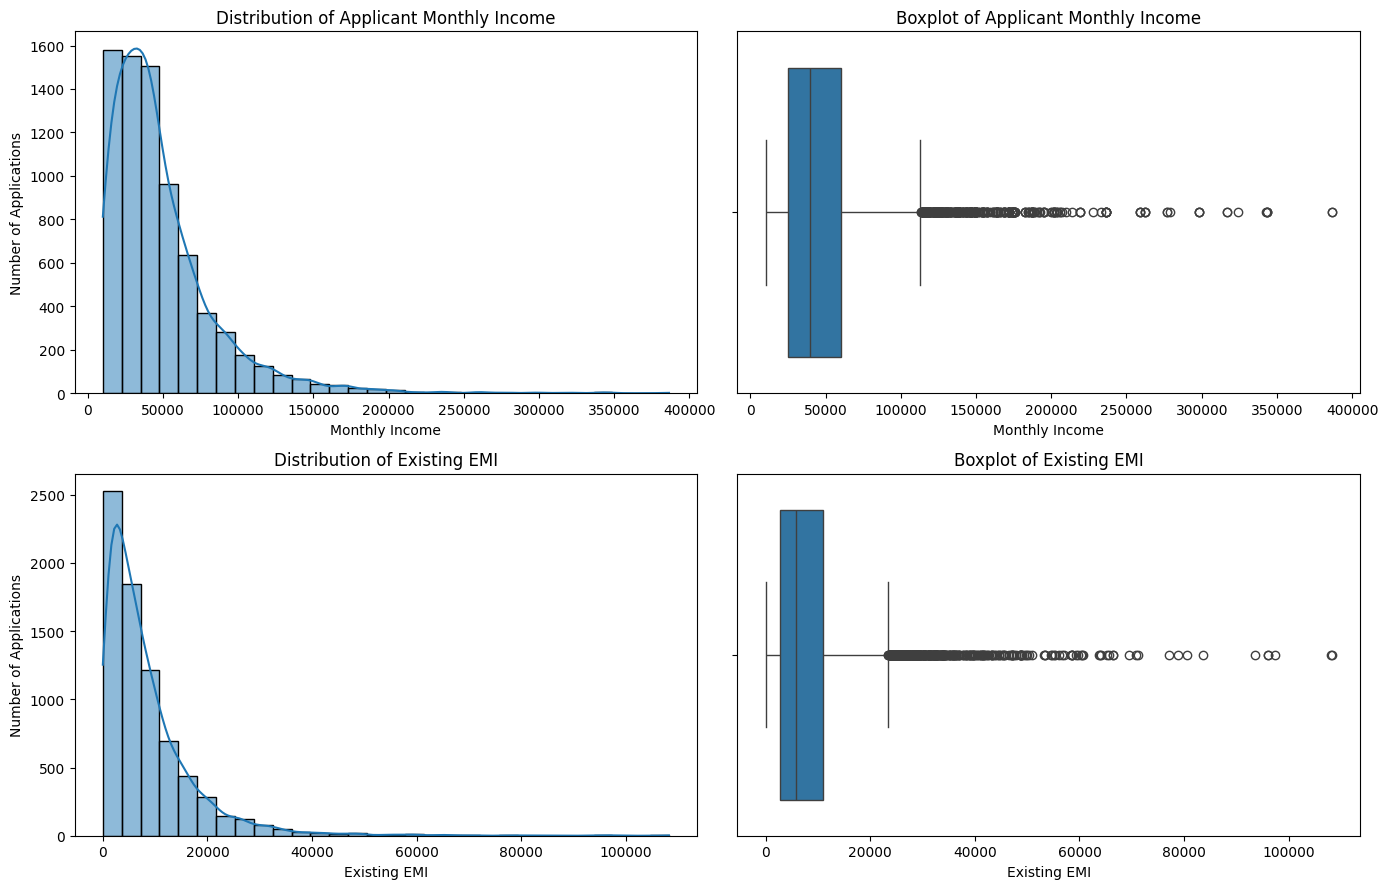

In [74]:
# Applicant monthly income and existing EMI visualizations

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Applicant monthly income - histogram
sns.histplot(
    data=loans,
    x="applicant_monthly_income",
    bins=30,
    kde=True,
    ax=axes[0, 0]
)

axes[0, 0].set_title("Distribution of Applicant Monthly Income")
axes[0, 0].set_xlabel("Monthly Income")
axes[0, 0].set_ylabel("Number of Applications")


# Applicant monthly income - boxplot
sns.boxplot(
    data=loans,
    x="applicant_monthly_income",
    ax=axes[0, 1]
)

axes[0, 1].set_title("Boxplot of Applicant Monthly Income")
axes[0, 1].set_xlabel("Monthly Income")


# Existing EMI - histogram
sns.histplot(
    data=loans,
    x="existing_emi",
    bins=30,
    kde=True,
    ax=axes[1, 0]
)

axes[1, 0].set_title("Distribution of Existing EMI")
axes[1, 0].set_xlabel("Existing EMI")
axes[1, 0].set_ylabel("Number of Applications")


# Existing EMI - boxplot
sns.boxplot(
    data=loans,
    x="existing_emi",
    ax=axes[1, 1]
)

axes[1, 1].set_title("Boxplot of Existing EMI")
axes[1, 1].set_xlabel("Existing EMI")

plt.tight_layout()
plt.show()

#### Key Findings

- Applicant monthly income ranges from **₹10,000 to ₹386,400**, with a median
  monthly income of **₹39,900** and an average of approximately **₹48,527**.

- The income distribution is strongly **right-skewed**, with most applicants
  concentrated in the lower-to-middle income range and a smaller number of
  applicants reporting substantially higher monthly incomes.

- Existing EMI ranges from **₹0 to ₹108,200**, with a median of **₹5,900** and
  an average of approximately **₹8,396**.

- Existing EMI is also strongly **right-skewed**, with most applicants having
  relatively moderate existing repayment obligations and a smaller number
  carrying considerably higher EMI commitments.

- Only **34 applicants (0.45%)** have zero existing EMI, indicating that almost
  all applicants already have some existing monthly repayment obligation.

- The boxplots identify several high-value observations for both income and EMI.
  These observations are retained during EDA because they may represent valid
  customer financial profiles rather than data-quality errors.

#### Modeling Consideration

The strong skewness and extreme values in income and EMI may influence some
machine-learning models. Appropriate preprocessing or transformations will be
considered during the modeling stage rather than modifying the raw values
during EDA.

### 11.5 Debt-to-Income Ratio Analysis

The debt-to-income (DTI) ratio measures the applicant's debt burden relative
to income and is an important indicator of repayment capacity.

This section examines the distribution of DTI values and their relationship
with loan approval decisions. Higher DTI values may indicate greater financial
obligations relative to the applicant's available income.

Debt-to-Income Ratio Summary
---------------------------------------------
count    7500.000000
mean        1.570814
std         1.023409
min         0.036000
25%         0.631000
50%         1.314000
75%         2.894250
max         3.000000
Name: debt_to_income_ratio, dtype: float64

Applications with DTI > 1:
4441

Percentage of Applications with DTI > 1:
59.21 %


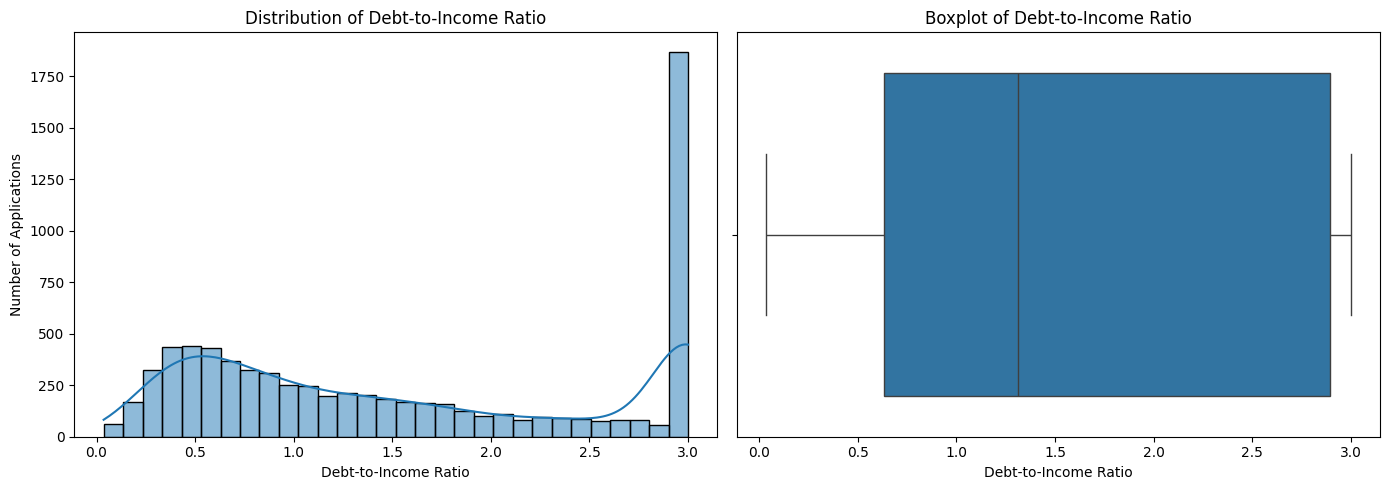

In [75]:
print("Debt-to-Income Ratio Summary")
print("-" * 45)
print(loans["debt_to_income_ratio"].describe())

print("\nApplications with DTI > 1:")
print((loans["debt_to_income_ratio"] > 1).sum())

print("\nPercentage of Applications with DTI > 1:")
print(
    round(
        (loans["debt_to_income_ratio"] > 1).mean() * 100,
        2
    ),
    "%"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=loans,
    x="debt_to_income_ratio",
    bins=30,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Distribution of Debt-to-Income Ratio")
axes[0].set_xlabel("Debt-to-Income Ratio")
axes[0].set_ylabel("Number of Applications")

sns.boxplot(
    data=loans,
    x="debt_to_income_ratio",
    ax=axes[1]
)

axes[1].set_title("Boxplot of Debt-to-Income Ratio")
axes[1].set_xlabel("Debt-to-Income Ratio")

plt.tight_layout()
plt.show()

DTI Summary by Approval Status
-------------------------------------------------------


,count,mean,median,min,max
approval_status,,,,,
Approved,3403,0.941,0.714,0.036,3.0
Rejected,3924,2.112,2.444,0.058,3.0
Under Review,173,1.682,1.481,0.093,3.0


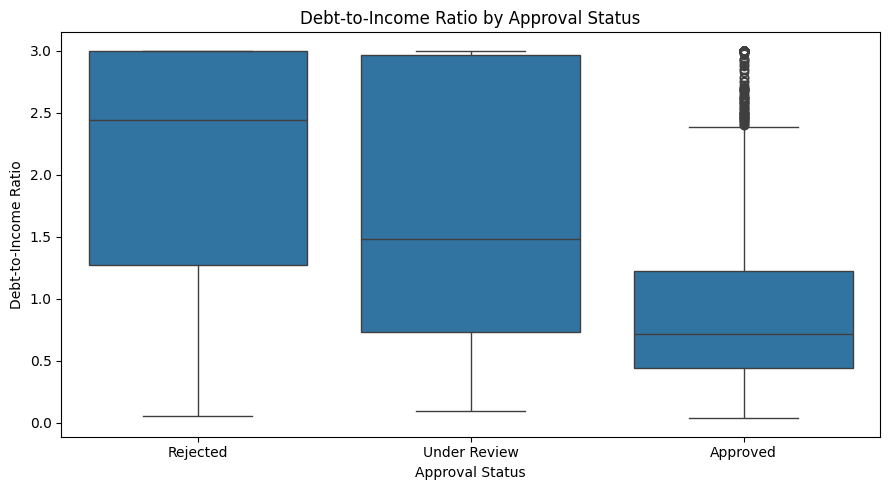

In [76]:
print("DTI Summary by Approval Status")
print("-" * 55)

dti_by_approval = loans.groupby("approval_status")[
    "debt_to_income_ratio"
].agg(["count", "mean", "median", "min", "max"]).round(3)

display(dti_by_approval)


plt.figure(figsize=(9, 5))

sns.boxplot(
    data=loans,
    x="approval_status",
    y="debt_to_income_ratio"
)

plt.title("Debt-to-Income Ratio by Approval Status")
plt.xlabel("Approval Status")
plt.ylabel("Debt-to-Income Ratio")

plt.tight_layout()
plt.show()

#### Key Findings

- The debt-to-income (DTI) ratio ranges from approximately **0.04 to 3.00**,
  with an average of **1.57** and a median of **1.31**.

- **4,441 applications (59.21%)** have a DTI ratio greater than 1, indicating
  that high DTI values are common in this dataset rather than isolated
  observations.

- A strong difference is observed across loan approval outcomes. Approved
  applications have a substantially lower average DTI (**0.94**) and median
  DTI (**0.71**) compared with rejected applications, which have an average
  DTI of **2.11** and median DTI of **2.44**.

- Applications under review fall between these groups, with an average DTI of
  approximately **1.68** and median DTI of **1.48**.

- The boxplot clearly shows that rejected applications are concentrated at
  higher DTI levels, while approved applications are concentrated at lower
  DTI levels.

- These results indicate that DTI is strongly associated with the historical
  loan approval decision in this dataset and may be an important variable for
  credit-risk analysis.

> **Note:** Approval status will be useful for EDA and business analysis, but
> it should not be used as a predictor of loan default because it represents
> a lending decision rather than information available independently of that
> decision.

### 11.6 Collateral Analysis

Collateral can reduce a lender's potential loss when a borrower defaults.
This section examines how frequently collateral is provided and whether
collateral availability differs across loan types.

Collateral Availability
---------------------------------------------


,Count,Percentage (%)
collateral_flag,,
1,3909,52.12
0,3591,47.88


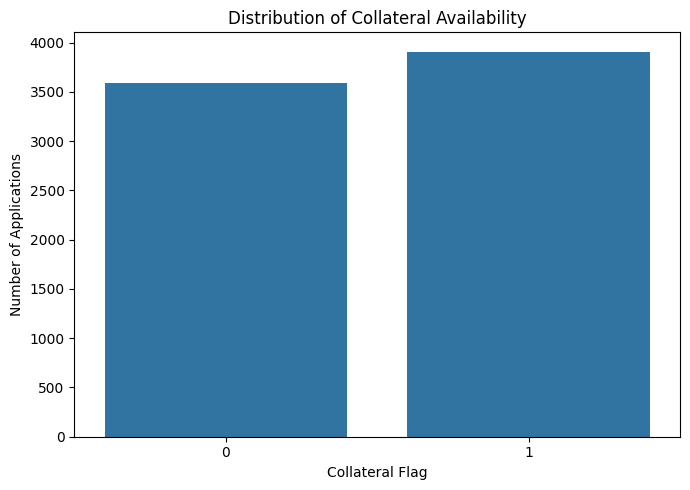

In [77]:
print("Collateral Availability")
print("-" * 45)

collateral_summary = (
    loans["collateral_flag"]
    .value_counts(dropna=False)
    .to_frame("Count")
)

collateral_summary["Percentage (%)"] = (
    collateral_summary["Count"] / len(loans) * 100
).round(2)

display(collateral_summary)

plt.figure(figsize=(7, 5))

sns.countplot(
    data=loans,
    x="collateral_flag"
)

plt.title("Distribution of Collateral Availability")
plt.xlabel("Collateral Flag")
plt.ylabel("Number of Applications")

plt.tight_layout()
plt.show()

In [78]:
print("Collateral Availability by Loan Type")
print("-" * 55)

collateral_by_type = pd.crosstab(
    loans["loan_type"],
    loans["collateral_flag"],
    margins=True
)

display(collateral_by_type)


collateral_pct = pd.crosstab(
    loans["loan_type"],
    loans["collateral_flag"],
    normalize="index"
).mul(100).round(2)

print("\nPercentage Distribution")
display(collateral_pct)

Collateral Availability by Loan Type
-------------------------------------------------------


collateral_flag,0,1,All
loan_type,,,
Auto,0,1375,1375
Business,884,154,1038
Education,592,135,727
Gold,0,608,608
Home,0,1252,1252
Personal,2115,385,2500
All,3591,3909,7500



Percentage Distribution


collateral_flag,0,1
loan_type,,
Auto,0.00,100.00
Business,85.16,14.84
Education,81.43,18.57
Gold,0.00,100.00
Home,0.00,100.00
Personal,84.60,15.40


Loan Approval Status
---------------------------------------------


,Count,Percentage (%)
approval_status,,
Rejected,3924,52.32
Approved,3403,45.37
Under Review,173,2.31


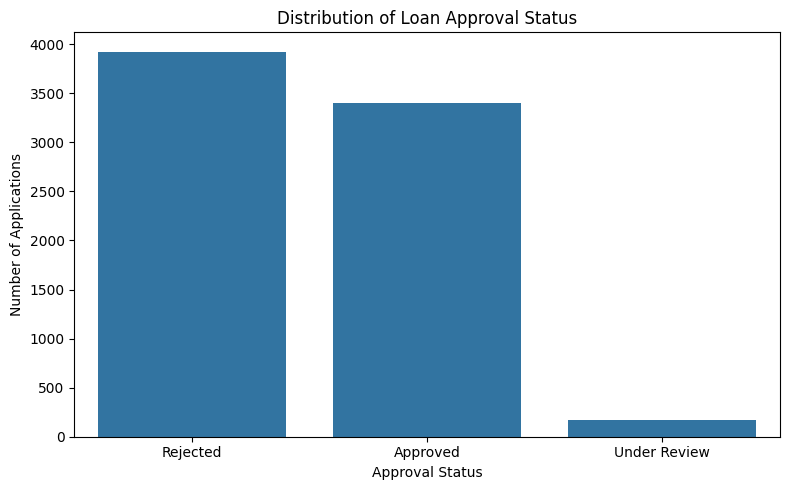

In [79]:
print("Loan Approval Status")
print("-" * 45)

approval_summary = (
    loans["approval_status"]
    .value_counts()
    .to_frame("Count")
)

approval_summary["Percentage (%)"] = (
    approval_summary["Count"] / len(loans) * 100
).round(2)

display(approval_summary)

plt.figure(figsize=(8, 5))

sns.countplot(
    data=loans,
    x="approval_status",
    order=loans["approval_status"].value_counts().index
)

plt.title("Distribution of Loan Approval Status")
plt.xlabel("Approval Status")
plt.ylabel("Number of Applications")

plt.tight_layout()
plt.show()

#### Key Findings

- Collateral is available for **3,909 applications (52.12%)**, while
  **3,591 applications (47.88%)** have no collateral.

- Collateral availability differs substantially across loan types.
  **Auto, Gold, and Home loans are 100% collateral-backed** in this dataset.

- In contrast, collateral is much less common for Business (**14.84%**),
  Education (**18.57%**), and Personal (**15.40%**) loans.

- The loan application outcomes are relatively balanced between rejected
  and approved applications. **52.32%** of applications were rejected and
  **45.37%** were approved, while only **2.31%** remained under review.

- These patterns indicate that collateral requirements are strongly related
  to loan type and should be considered during credit-risk analysis.

In [80]:
print("Approved Amount Summary")
print("-" * 45)

print(loans["approved_amount"].describe())

print("\nMissing Approved Amount:")
print(loans["approved_amount"].isna().sum())

print("\nApproved Amount by Approval Status")
print("-" * 45)

display(
    loans.groupby("approval_status")["approved_amount"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

Approved Amount Summary
---------------------------------------------
count    7.500000e+03
mean     5.883009e+05
std      1.288144e+06
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      6.450000e+05
max      1.171600e+07
Name: approved_amount, dtype: float64

Missing Approved Amount:
0

Approved Amount by Approval Status
---------------------------------------------


,count,mean,median,min,max
approval_status,,,,,
Approved,3403,1296578.61,749000.0,27000,11716000
Rejected,3924,0.00,0.0,0,0
Under Review,173,0.00,0.0,0,0


In [81]:
print("Disbursement Status")
print("-" * 45)

disbursement_summary = (
    loans["disbursed_flag"]
    .value_counts(dropna=False)
    .to_frame("Count")
)

disbursement_summary["Percentage (%)"] = (
    disbursement_summary["Count"] / len(loans) * 100
).round(2)

display(disbursement_summary)

print("\nDisbursement by Approval Status")
print("-" * 45)

display(
    pd.crosstab(
        loans["approval_status"],
        loans["disbursed_flag"],
        margins=True
    )
)

Disbursement Status
---------------------------------------------


,Count,Percentage (%)
disbursed_flag,,
0,4097,54.63
1,3403,45.37



Disbursement by Approval Status
---------------------------------------------


disbursed_flag,0,1,All
approval_status,,,
Approved,0,3403,3403
Rejected,3924,0,3924
Under Review,173,0,173
All,4097,3403,7500


In [82]:
print("Loan Default Target Distribution")
print("-" * 50)

default_counts = loans["loan_default"].value_counts(dropna=False)

print(default_counts)

print("\nPercentage Distribution")
print("-" * 50)

print(
    (loans["loan_default"]
     .value_counts(dropna=False, normalize=True) * 100)
     .round(2)
)

print("\nKnown vs Missing Target")
print("-" * 50)

print("Known loan_default:",
      loans["loan_default"].notna().sum())

print("Missing loan_default:",
      loans["loan_default"].isna().sum())

print("\nDefault Distribution Among Known Outcomes Only")
print("-" * 50)

known_default = loans[loans["loan_default"].notna()]

print(known_default["loan_default"].value_counts())

print("\nPercentage Among Known Outcomes")
print(
    (known_default["loan_default"]
     .value_counts(normalize=True) * 100)
     .round(2)
)

Loan Default Target Distribution
--------------------------------------------------
loan_default
NaN    4097
0.0    2606
1.0     797
Name: count, dtype: int64

Percentage Distribution
--------------------------------------------------
loan_default
NaN    54.63
0.0    34.75
1.0    10.63
Name: proportion, dtype: float64

Known vs Missing Target
--------------------------------------------------
Known loan_default: 3403
Missing loan_default: 4097

Default Distribution Among Known Outcomes Only
--------------------------------------------------
loan_default
0.0    2606
1.0     797
Name: count, dtype: int64

Percentage Among Known Outcomes
loan_default
0.0    76.58
1.0    23.42
Name: proportion, dtype: float64


### Key Findings — Approval, Disbursement and Loan Default

- Out of 7,500 loan applications, 3,403 (45.37%) were approved and disbursed, while 4,097 (54.63%) were not disbursed.
- Approved applications received a positive approved amount, whereas rejected and under-review applications had an approved amount of 0.
- Loan default information is available only for the 3,403 loans with observed outcomes. The remaining 4,097 applications have missing `loan_default` values.
- Among the 3,403 loans with known default outcomes, 2,606 (76.58%) did not default and 797 (23.42%) defaulted.
- Therefore, the machine-learning dataset for default prediction should use only rows where `loan_default` is known.
- The target variable is moderately imbalanced, with approximately 23.42% defaults and 76.58% non-defaults. This means model evaluation should consider Recall, F1-score and ROC-AUC rather than relying only on Accuracy.
- `approval_status`, `approved_amount` and `disbursed_flag` should not be used as predictors for the default model because they represent information associated with or occurring after the lending decision and could cause data leakage.

In [83]:
print("Application Date Information")
print("-" * 50)

print(loans["application_date"].head())
print("\nData type:")
print(loans["application_date"].dtype)

print("\nDate range:")
application_dates = pd.to_datetime(loans["application_date"])

print("Earliest date:", application_dates.min())
print("Latest date:", application_dates.max())

Application Date Information
--------------------------------------------------
0   2022-12-20
1   2022-12-15
2   2022-10-05
3   2022-08-29
4   2024-05-22
Name: application_date, dtype: datetime64[ns]

Data type:
datetime64[ns]

Date range:
Earliest date: 2022-07-01 00:00:00
Latest date: 2024-06-29 00:00:00


In [84]:
# Create a proper datetime version
loans["application_date"] = pd.to_datetime(loans["application_date"])

# Create application month
loans["application_month"] = loans["application_date"].dt.to_period("M")

monthly_applications = (
    loans.groupby("application_month")
    .size()
    .reset_index(name="application_count")
)

print("Monthly Application Volume")
print("-" * 50)
print(monthly_applications)

Monthly Application Volume
--------------------------------------------------
   application_month  application_count
0            2022-07                326
1            2022-08                317
2            2022-09                287
3            2022-10                342
4            2022-11                305
5            2022-12                332
6            2023-01                357
7            2023-02                265
8            2023-03                286
9            2023-04                341
10           2023-05                318
11           2023-06                306
12           2023-07                294
13           2023-08                296
14           2023-09                298
15           2023-10                354
16           2023-11                321
17           2023-12                336
18           2024-01                309
19           2024-02                304
20           2024-03                291
21           2024-04                302
22

## 12. Transaction Analysis

In [85]:
# Basic overview of transactions dataset

print("Transactions Dataset Overview")
print("-" * 50)

print("Shape:", transactions.shape)

print("\nColumns:")
print(transactions.columns.tolist())

print("\nData Types:")
print(transactions.dtypes)

print("\nMissing Values:")
print(transactions.isnull().sum())

print("\nDuplicate Rows:")
print(transactions.duplicated().sum())

Transactions Dataset Overview
--------------------------------------------------
Shape: (40079, 8)

Columns:
['transaction_id', 'customer_id', 'transaction_date', 'transaction_type', 'category', 'channel', 'amount', 'balance_after']

Data Types:
transaction_id              object
customer_id                 object
transaction_date    datetime64[ns]
transaction_type            object
category                    object
channel                     object
amount                     float64
balance_after              float64
dtype: object

Missing Values:
transaction_id      0
customer_id         0
transaction_date    0
transaction_type    0
category            0
channel             0
amount              0
balance_after       0
dtype: int64

Duplicate Rows:
0


In [87]:
# Transaction type, category, and channel distributions

print("TRANSACTION TYPE")
print("-" * 50)

print(transactions["transaction_type"].value_counts())

print("\nPercentage:")
print(
    transactions["transaction_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


print("\nTRANSACTION CATEGORY")
print("-" * 50)

print(transactions["category"].value_counts())

print("\nPercentage:")
print(
    transactions["category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


print("\nTRANSACTION CHANNEL")
print("-" * 50)

print(transactions["channel"].value_counts())

print("\nPercentage:")
print(
    transactions["channel"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

TRANSACTION TYPE
--------------------------------------------------
transaction_type
Debit     30844
Credit     9235
Name: count, dtype: int64

Percentage:
transaction_type
Debit     76.96
Credit    23.04
Name: proportion, dtype: float64

TRANSACTION CATEGORY
--------------------------------------------------
category
Shopping          6466
Salary            5612
Utilities         4781
EMI               4770
Dining            3639
ATM Withdrawal    3240
Transfer Out      2788
Transfer In       2443
Travel            2403
Investment        1597
Refund            1180
Insurance         1160
Name: count, dtype: int64

Percentage:
category
Shopping          16.13
Salary            14.00
Utilities         11.93
EMI               11.90
Dining             9.08
ATM Withdrawal     8.08
Transfer Out       6.96
Transfer In        6.10
Travel             6.00
Investment         3.98
Refund             2.94
Insurance          2.89
Name: proportion, dtype: float64

TRANSACTION CHANNEL
--------------

### Transaction Type, Category, and Channel Analysis

#### Key Findings

- The transaction dataset contains **40,079 transactions**, of which
  **30,844 (76.96%)** are debit transactions and **9,235 (23.04%)** are
  credit transactions. This indicates that outgoing transactions occur much
  more frequently than incoming transactions.

- **Shopping** is the most frequent transaction category, accounting for
  **6,466 transactions (16.13%)**, followed by **Salary (14.00%)**,
  **Utilities (11.93%)**, and **EMI (11.90%)**.

- EMI transactions account for a substantial portion of transaction activity
  and may provide useful information when constructing customer-level
  repayment and cash-flow features.

- Other common spending categories include Dining (**9.08%**),
  ATM Withdrawal (**8.08%**), Transfer Out (**6.96%**), and Travel
  (**6.00%**).

- **UPI is the dominant transaction channel**, accounting for
  **42.39%** of all transactions.

- Debit Card (**19.77%**) and Net Banking (**15.03%**) are the next most
  frequently used channels, while Branch transactions are the least common
  at **4.86%**.

#### EDA Implication

The transaction data contains information about customer inflows, outflows,
repayment activity, spending behavior, and account usage. Because multiple
transactions belong to the same customer, these records should not be joined
directly to individual loan applications. Customer-level transaction features
will be created through aggregation before integration with the modeling
dataset.

In [88]:
print("Transaction Amount Summary")
print("-" * 50)
print(transactions["amount"].describe())

print("\nBalance After Transaction Summary")
print("-" * 50)
print(transactions["balance_after"].describe())

print("\nTransaction Date Range")
print("-" * 50)
print("Earliest:", transactions["transaction_date"].min())
print("Latest:", transactions["transaction_date"].max())

Transaction Amount Summary
--------------------------------------------------
count     40079.000000
mean      14040.707134
std       18835.280337
min         100.390000
25%        3566.420000
50%        7928.110000
75%       16313.230000
max      359766.320000
Name: amount, dtype: float64

Balance After Transaction Summary
--------------------------------------------------
count    4.007900e+04
mean     8.000340e+04
std      7.786162e+04
min      1.000000e+02
25%      2.848772e+04
50%      5.757170e+04
75%      1.051002e+05
max      1.268816e+06
Name: balance_after, dtype: float64

Transaction Date Range
--------------------------------------------------
Earliest: 2024-01-01 00:00:00
Latest: 2024-06-29 00:00:00


In [89]:
transactions_per_customer = (
    transactions.groupby("customer_id")
    .size()
)

print("Transactions per Customer Summary")
print("-" * 50)
print(transactions_per_customer.describe())

print("\nUnique Customers in Transaction Data:")
print(transactions["customer_id"].nunique())

print("\nCustomers with No Transactions:")
print(
    customers["customer_id"].nunique()
    - transactions["customer_id"].nunique()
)

print("\nAverage Transactions per Customer:")
print(round(transactions_per_customer.mean(), 2))

Transactions per Customer Summary
--------------------------------------------------
count    5000.000000
mean        8.015800
std         2.584122
min         4.000000
25%         6.000000
50%         8.000000
75%        10.000000
max        12.000000
dtype: float64

Unique Customers in Transaction Data:
5000

Customers with No Transactions:
0

Average Transactions per Customer:
8.02


In [90]:
# Create customer-level transaction features

# Separate inflow and outflow amounts
transactions["inflow"] = transactions["amount"].where(
    transactions["transaction_type"] == "Credit", 0
)

transactions["outflow"] = transactions["amount"].where(
    transactions["transaction_type"] == "Debit", 0
)

# Identify EMI outflow
transactions["emi_outflow"] = transactions["amount"].where(
    (transactions["transaction_type"] == "Debit") &
    (transactions["category"] == "EMI"),
    0
)

# Aggregate transactions by customer
transaction_features = (
    transactions.groupby("customer_id")
    .agg(
        total_inflow_6m=("inflow", "sum"),
        total_outflow_6m=("outflow", "sum"),
        emi_outflow_6m=("emi_outflow", "sum"),
        avg_balance=("balance_after", "mean"),
        transaction_count=("transaction_id", "count")
    )
    .reset_index()
)

# Net cash flow
transaction_features["net_cash_flow_6m"] = (
    transaction_features["total_inflow_6m"]
    - transaction_features["total_outflow_6m"]
)

# Inflow / outflow ratio
transaction_features["inflow_outflow_ratio"] = (
    transaction_features["total_inflow_6m"]
    / transaction_features["total_outflow_6m"].replace(0, np.nan)
)

print("Customer-Level Transaction Features")
print("-" * 60)

print("Shape:", transaction_features.shape)

print("\nColumns:")
print(transaction_features.columns.tolist())

print("\nFirst 5 rows:")
print(transaction_features.head())

print("\nMissing Values:")
print(transaction_features.isnull().sum())

Customer-Level Transaction Features
------------------------------------------------------------
Shape: (5000, 8)

Columns:
['customer_id', 'total_inflow_6m', 'total_outflow_6m', 'emi_outflow_6m', 'avg_balance', 'transaction_count', 'net_cash_flow_6m', 'inflow_outflow_ratio']

First 5 rows:
  customer_id  total_inflow_6m  total_outflow_6m  emi_outflow_6m  \
0  CUST100001             0.00          18570.47            0.00   
1  CUST100002             0.00           8544.61            0.00   
2  CUST100003         14192.69          25230.16         1278.10   
3  CUST100004         73985.80          27026.15         7280.57   
4  CUST100005             0.00          43285.20            0.00   

    avg_balance  transaction_count  net_cash_flow_6m  inflow_outflow_ratio  
0  39151.317500                  4         -18570.47              0.000000  
1  16165.722500                  4          -8544.61              0.000000  
2  20026.796364                 11         -11037.47              0.

In [91]:
# Check customers with missing inflow/outflow ratio

missing_ratio = transaction_features[
    transaction_features["inflow_outflow_ratio"].isna()
]

print("Customers with Missing Inflow/Outflow Ratio")
print("-" * 60)

print(
    missing_ratio[
        [
            "customer_id",
            "total_inflow_6m",
            "total_outflow_6m",
            "net_cash_flow_6m",
            "inflow_outflow_ratio"
        ]
    ]
)

Customers with Missing Inflow/Outflow Ratio
------------------------------------------------------------
     customer_id  total_inflow_6m  total_outflow_6m  net_cash_flow_6m  \
443   CUST100444         88610.71               0.0          88610.71   
3289  CUST103290        134696.50               0.0         134696.50   

      inflow_outflow_ratio  
443                    NaN  
3289                   NaN  


In [92]:
# Summary statistics of engineered transaction features

print("Transaction Feature Summary")
print("-" * 60)

print(
    transaction_features[
        [
            "total_inflow_6m",
            "total_outflow_6m",
            "emi_outflow_6m",
            "avg_balance",
            "transaction_count",
            "net_cash_flow_6m",
            "inflow_outflow_ratio"
        ]
    ].describe()
)

Transaction Feature Summary
------------------------------------------------------------
       total_inflow_6m  total_outflow_6m  emi_outflow_6m    avg_balance  \
count      5000.000000       5000.000000     5000.000000    5000.000000   
mean      59233.898612      53313.601636     8365.725110   80419.686513   
std       69523.516107      46359.793929    13125.544164   62152.147039   
min           0.000000          0.000000        0.000000    6595.248333   
25%       11513.877500      21976.137500        0.000000   38847.042333   
50%       38584.525000      39555.710000     3254.410000   63889.282727   
75%       82953.042500      69634.925000    11933.577500  100614.269875   
max      695246.800000     478836.730000   147367.780000  629632.580000   

       transaction_count  net_cash_flow_6m  inflow_outflow_ratio  
count        5000.000000       5000.000000           4998.000000  
mean            8.015800       5920.296976              1.548152  
std             2.584122      6452

In [94]:
# Check customer ID coverage across datasets

print("Customer ID Coverage")
print("-" * 60)

print("Customers dataset:", customers["customer_id"].nunique())
print("Credit history:", credit["customer_id"].nunique())
print("Loan applications:", loans["customer_id"].nunique())
print("Transaction features:", transaction_features["customer_id"].nunique())

print("\nLoan applications:", len(loans))
print("Unique loan applicants:", loans["customer_id"].nunique())

Customer ID Coverage
------------------------------------------------------------
Customers dataset: 5000
Credit history: 5000
Loan applications: 3904
Transaction features: 5000

Loan applications: 7500
Unique loan applicants: 3904


In [96]:
# Check whether customer IDs match across customer-level datasets

customer_ids = set(customers["customer_id"])
credit_ids = set(credit["customer_id"])
transaction_ids = set(transaction_features["customer_id"])

print("ID Matching Check")
print("-" * 60)

print("Customers missing from credit history:",
      len(customer_ids - credit_ids))

print("Customers missing from transaction features:",
      len(customer_ids - transaction_ids))

print("Credit customers not in customers table:",
      len(credit_ids - customer_ids))

print("Transaction customers not in customers table:",
      len(transaction_ids - customer_ids))

ID Matching Check
------------------------------------------------------------
Customers missing from credit history: 0
Customers missing from transaction features: 0
Credit customers not in customers table: 0
Transaction customers not in customers table: 0


## 13. EDA Summary

The exploratory data analysis identified important patterns across customer,
credit history, loan application, and transaction data.

Key observations include:

- The loan default target is available for 3,403 disbursed loans, with a
  default rate of 23.42%.
- Credit score is negatively associated with late payments, prior defaults,
  and credit utilization.
- Debt-to-income ratio differs substantially between approved and rejected
  applications.
- Transaction data covers all 5,000 customers and provides useful information
  about customer inflows, outflows, EMI payments, balances, and cash flow.
- Several financial variables are right-skewed and contain high-value
  observations that should be considered during preprocessing.
- `credit_utilization_ratio` and the engineered `debt_to_limit` feature are
  almost perfectly correlated and should not both be used in the final model.
- Post-decision variables such as `approval_status`, `approved_amount`,
  `decision_date`, and `disbursed_flag` must be excluded from default
  prediction to prevent data leakage.

The next stage of the project will focus on feature engineering, dataset
integration, and preparation of the final modeling dataset.